# Latent Volatility Modelling Through Bayesian Machine Learning

This project aims to estimate and identify the latent volatility trends in the market. 

In particular, credible intervals for latent volatility are generated through Bayesian inference methods using daily S&P 500 market data.

The volatility models used in this project, are developed on priors, tested on regression conditions (in-sample testing) and then tested under sequential updating (out-of-sample-testing).


## Value of Volatility Modelling 

Accurately estimating the latent volatility is particularly useful for market traders. 

In particular, traders can dynamically hedge their trading positions where theoretically the size of their position should be inversely proportion to volatility. 

Additionally, they can potentially switch strategies depending on if the latent volatility passes a certain threshold (or a certain credible interval). 

Furthermore, they can easily identify mispriced options since quoted options generally have an associated implied volatility. 

All of these techniques can be used to generate a profit.

## What is Volatility?

Volatility is defined as the standard deviation of the daily log returns.

Note that, there is no stated volatility published by the stock market at the end of the day unlike the stock price making it an unobservable 'latent' quantity.

Therefore, the effectiveness of a latent volatility model needs to be tested indirectly through different metrics. 

## Import and Process Data

First, the data needs to be imported.

There are 3 sets of data that need to be extracted from Yahoo Finance

2013 - 2017 for developing priors

2018 - 2021 for testing whether models under regression conditions

2022 - 2025 for testing whether models under sequential updating

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
np.random.seed(42)

# Download data
full_data = yf.download("SPY",
                         start="2013-01-01",
                         end="2025-12-31",
                         auto_adjust=True,
                         progress=False)


Below, the daily log returns are computed for each time period.

In [2]:
def data_returns(data):
    return np.log(data["Close"]).diff().dropna()
# returns at time t are price at time t/t-1
full_returns = data_returns(full_data)

# Split by date
prior_returns      = full_returns["2013-01-01":"2017-12-31"]
regression_returns = full_returns["2018-01-01":"2021-12-31"]
sequential_returns = full_returns["2022-01-01":"2025-12-31"]

# 1d for computation
prior_returns_1d      = prior_returns.values.flatten()
regression_returns_1d = regression_returns.values.flatten()
sequential_returns_1d = sequential_returns.values.flatten()

# check type/date
print(type(prior_returns))          
print(type(prior_returns_1d))        

print(prior_returns.shape)          
print(prior_returns_1d.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(1258, 1)
(1258,)


### Dates indices for all periods

For future computation, it makes sense to lay out the date indices for all the periods.

In [3]:
# Prior period
prior_dates = prior_returns.index
print(f"Prior:      {prior_dates[0].date()} to {prior_dates[-1].date()}, "
      f"n={len(prior_dates)}")

# Regression period
regression_dates = regression_returns.index
print(f"Regression: {regression_dates[0].date()} to {regression_dates[-1].date()}, "
      f"n={len(regression_dates)}")

# Sequential period
sequential_dates = sequential_returns.index
print(f"Sequential: {sequential_dates[0].date()} to {sequential_dates[-1].date()}, "
      f"n={len(sequential_dates)}")



Prior:      2013-01-03 to 2017-12-29, n=1258
Regression: 2018-01-02 to 2021-12-31, n=1008
Sequential: 2022-01-03 to 2025-12-30, n=1002


# General Procedure

3 models will be tested, a baseline rolling average, a time series model and a stochastic model.

Note that each model will be developed and then tested on both regression and sequential data. At the end of this notebook, the models will be compared to each other

The model's effectiveness is tested using different metrics like QLIKE, Realized Volatility Coverage, PIT Histogram and Return Coverage. 

## Regression

## Regression Conditions

For Bayesian methods, the priors developed based on 2013-2017 data are then updated using data from 2018-2021 to obtain posterior samples for the model parameters. 

This is an in-sample test as these parameters are then propagated forward through the regression data itself to obtain implied volatility paths.

### Why Regression?

Regression is useful to test if the volatility modelling approach has some merit. 

This is because regression is essentially the best case scenario (i.e it gives best fit for volatility paths based on a complete knowledge of the returns).

Furthermore, it is useful to understand why models may fail (only doing out of sample testing would give information on why the model failed, (is it because the model itself is misspecified or is it because the model can't generalize to new data))



## Sequential Updating

Starting with the posterior samples from the regression, the models are sequentially updated over windows from 2022-2025.

In each window, the volatility is forecasted using the previous window's posterior samples. Then, the posterior is updated by treating the previous windows posterior as the prior (this is done by fitting the posterior samples to the distributions of the original priors) and conditioning on the window's data. 

Therefore, this is a truly out-of-sample test since both the model's realized volatility and measurement noise for a window are only based on data prior to the window.

This is the final test, can the model predict future volatility based on current information. 

## Baseline: Rolling Average

The rolling average calculates the volatility over the past month 21 days, and uses it as the estimate for the volatility over the next 21 days

This volatility is the sample standard deviation of the previous $h$ log returns:

\begin{equation*}
    \hat{\sigma}_t^{roll} = \sqrt{\frac{1}{h-1}
    \sum_{i=0}^{h-1}(r_{t-i} - \bar{r}_t)^2}
\end{equation*}
where $\bar{r}_t = \frac{1}{h}\sum_{i=0}^{h-1} r_{t-i}$ is the rolling mean and $h=21$

This method is a naive baseline since it is independent of any model assumptions and is quickly computable from past returns. 

Note that since this baseline isn't a model with parameters, there is no real difference between the in-sample test and out-of-sample test. All the regression/sequential things can be calculated immediately.

Furthermore, the model isn't Bayesian so there are no confidence intervals.

In [6]:
def rolling_vol(returns, h=21):
    return returns.rolling(h).std()

full_rolling = rolling_vol(full_returns)
rolling_prior      = full_rolling[prior_dates[0].date():prior_dates[-1].date()].dropna()
rolling_regression = full_rolling[regression_dates[0].date():regression_dates[-1].date()].dropna()
rolling_sequential = full_rolling[sequential_dates[0].date():sequential_dates[-1].date()].dropna()

rolling_prior_1d      = rolling_prior.values.flatten()
rolling_regression_1d = rolling_regression.values.flatten()
rolling_sequential_1d = rolling_sequential.values.flatten()
print(len(rolling_prior_1d))
print(len(rolling_regression_1d))
print(len(rolling_sequential_1d))

1238
1008
1002


## Metrics


## Realized Volatility

### What is Realized Volatility

The monthly realized volatility is the standard deviation of log returns over the next 21 log returns. It represents the average volatility throughout that period by assuming constant volatility throughout this period.

In particular, 

\begin{equation*}
    \hat{\sigma}_t^{empirical} = \sqrt{\frac{1}{h-1}
    \sum_{i=1}^{h}(r_{t+i} - \bar{r}_t)^2}
\end{equation*}

where $r_{t}=ln(\frac{P_{t}}{P_{t-1}})$ and $\bar{r}_t = \frac{1}{h}\sum_{i=1}^{h} r_{t+i}$ and $h=21$ 


### Why Realized Volatility?

Volatility comparisons are generally done over a long time period i.e using more return values since it reduces estimation error.

In [15]:
# directly compute realized volatility
def realized_vol(returns, h=21):
    return returns.rolling(h).std().shift(-h)

full_rv = realized_vol(full_returns)
print(full_rv.index)
rv_prior      = full_rv[prior_dates[0].date():prior_dates[-1].date()].dropna()
rv_regression = full_rv[regression_dates[0].date():regression_dates[-1].date()].dropna()
rv_sequential = full_rv[sequential_dates[0].date():sequential_dates[-1].date()].dropna()

rv_prior_1d      = rv_prior.values.flatten()
rv_regression_1d = rv_regression.values.flatten()
rv_sequential_1d = rv_sequential.values.flatten()
print(full_rv)

DatetimeIndex(['2013-01-03', '2013-01-04', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10', '2013-01-11', '2013-01-14',
               '2013-01-15', '2013-01-16',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', name='Date', length=3268, freq=None)
Ticker           SPY
Date                
2013-01-03  0.004763
2013-01-04  0.005099
2013-01-07  0.005010
2013-01-08  0.004951
2013-01-09  0.005018
...              ...
2025-12-23       NaN
2025-12-24       NaN
2025-12-26       NaN
2025-12-29       NaN
2025-12-30       NaN

[3268 rows x 1 columns]


Note that the final values have NaN since computing their realized volatility would require data from 2026 onwards.

In [16]:
# RV dates 
rv_prior_dates      = prior_dates[:len(rv_prior_1d)]
rv_regression_dates = regression_dates[:len(rv_regression_1d)]
rv_sequential_dates = sequential_dates[:len(rv_sequential_1d)]

print(f"\nRV prior:      {rv_prior_dates[0].date()} to {rv_prior_dates[-1].date()}, "
      f"n={len(rv_prior_dates)}")
print(f"RV regression: {rv_regression_dates[0].date()} to {rv_regression_dates[-1].date()}, "
      f"n={len(rv_regression_dates)}")
print(f"RV sequential: {rv_sequential_dates[0].date()} to {rv_sequential_dates[-1].date()}, "
      f"n={len(rv_sequential_dates)}")


RV prior:      2013-01-03 to 2017-12-29, n=1258
RV regression: 2018-01-02 to 2021-12-31, n=1008
RV sequential: 2022-01-03 to 2025-11-28, n=981


### Model Realized Volatility

In order to use the realized volatility for a fair comparison, a model equivalent realized volatility is required.

For the rolling average, this is relatively straightforward since the rolling volatility estimates are in the form of realized volatility.

### QLIKE Comparison with Realized Voalatility

### What is QLIKE?

The QLIKE estimator compares the pointwise estimates of realized volatility.

\begin{equation*}
    \text{QLIKE}(\hat{\sigma}_t, RV_t) = \frac{RV_t^2}{\hat{\sigma}_t^2} 
    - \log\!\left(\frac{RV_t^2}{\hat{\sigma}_t^2}\right) - 1
\end{equation*}

### Why QLIKE?

QLIKE Loss is used since it takes into account the volatility asymmetry (generally underpredicting volatility is worse than overpredicting volatility)

Furthermore, the QLIKE loss is known to work well with volatility proxies (like realized volatility).

### Interpreting QLIKE

Simply put, a lower mean QLIKE loss is better since it suggests the model closely fits the realized volatility. 

In [17]:
from scipy import stats
import numpy as np

def qlike(sigma, rv):
    ratio = rv**2 / sigma**2
    return ratio - np.log(ratio) - 1

# QLIKE Losses
nr = min(len(rolling_regression_1d), len(rv_regression_1d))
ns = min(len(rolling_sequential_1d), len(rv_sequential_1d))

ql_rolling_regression = qlike(rolling_regression_1d[:nr], rv_regression_1d[:nr])
ql_rolling_sequential = qlike(rolling_sequential_1d[:ns], rv_sequential_1d[:ns])

print(f"QLIKE (regression, rolling):  mean = {ql_rolling_regression.mean():.4f}")
print(f"QLIKE (sequential, rolling):  mean = {ql_rolling_sequential.mean():.4f}")

QLIKE (regression, rolling):  mean = 1.2659
QLIKE (sequential, rolling):  mean = 0.3955


Note that the high QLIKE values in the regression period is likely due to COVID.

In [4]:
def rolling_vol(returns, h=21):
    return returns.rolling(h).std()

full_rolling = rolling_vol(full_returns)
rolling_prior      = full_rolling["2013-01-01":"2017-12-31"].dropna()
rolling_regression = full_rolling["2018-01-01":"2021-12-31"].dropna()
rolling_sequential = full_rolling["2022-01-01":"2025-12-31"].dropna()

rolling_prior_1d      = rolling_prior.values.flatten()
rolling_regression_1d = rolling_regression.values.flatten()
rolling_sequential_1d = rolling_sequential.values.flatten()


<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(1238, 1)
(1238,)


## QLIKE Method

In [ ]:
from scipy import stats

def qlike(sigma, rv):
    ratio = rv**2 / sigma**2
    return ratio - np.log(ratio) - 1

# ── Rolling vol forecast — RV shifted back 21 days ─────────────────────
rolling_vol_reg = full_rv.shift(21)["2018-01-01":"2021-12-31"].dropna().values.flatten()

# ── Align all lengths ──────────────────────────────────────────────────
n_dm = min(len(rv_regression_1d),
           len(rolling_vol_reg),
           len(sigma_mean_egarch),
           len(sigma_mean_sv))

rv_dm = rv_regression_1d[:n_dm]

# ── QLIKE losses ───────────────────────────────────────────────────────
ql_rolling = qlike(rolling_vol_reg[:n_dm], rv_dm)
ql_egarch  = qlike(sigma_mean_egarch[:n_dm], rv_dm)
ql_sv      = qlike(sigma_mean_sv[:n_dm], rv_dm)

# ── Results ────────────────────────────────────────────────────────────
print("Mean QLIKE (lower = better):")
print(f"Rolling: {ql_rolling.mean():.6f}")
print(f"EGARCH:  {ql_egarch.mean():.6f}")
print(f"SV:      {ql_sv.mean():.6f}")

## Realized Volatility

### What is Realized Volatility

The monthly realized volatility is the  (standard deviation of log returns over the next 21 log returns). It represents the average volatility throughout that period by assuming the volatility is constant through this period.


In particular, 
\begin{equation*}
    \hat{\sigma}_t^{empirical} = \sqrt{\frac{1}{h-1}
    \sum_{i=1}^{h}(r_{t+i} - \bar{r}_t)^2}
\end{equation*}

where $r_{t}=ln(\frac{P_{t}}{P_{t-1}})$ and $\bar{r}_t = \frac{1}{h}\sum_{i=1}^{h} r_{t+i}$ and $h=21$ 

is compared with 
\begin{equation*}
    \hat{\sigma}_t^{model} =\sqrt{\frac{1}{h-1}\sum_{i=1}^{h} \sigma_{t+i}^{2}}
\end{equation*}

where $\sigma_{t}$ is the model's instantaneous volatility estimate at time t.

### Why Realized Volatility?

In the empirical case, the volatility is assumed to be the same for every day in the window itself. Therefore, it is calculated using the standard deviation of the entire window.

On the other hand, the volatility model gives a different volatility estimate for each day. For a window-window comparison, the root mean square of the model's volatility is taken. 

Note that the volatility comparisons are generally done over several iterations since it reduces estimation error of the model.

### Sources of Error

Note that there are still some sources of error for after this realized voaltiltity. Note that the model itself not be specified correctly. Additionally, there is also a risk of noise estimates and approximation error factored into the model.

### Interpreting Realized Volatility

For a perfect model, the realized volatilities should be the same. However, there are sources of error (other than the model error that result in this not being the case). First, approximation error since 21 returns are being used (relatively small amount), Second factoring in noise estimates caused by the model

As discussed in the volatility section $\hat\sigma_{t}^{empirical}$ which is derived through estimates of the actual realized volatility is compared to $\hat\sigma_{t}^{model}$ which measures actual realized volatility. 

For a legitimate comparison with the empirical, the standard deviation error (noise estimate) needs to be factored into the true model. For simplicity, a log normal model is used.

Are some of these systematic errors vs model errors?

Clearly the $r_{t+1}-r_{t}$ isn't expected to be equal to $\sigma_{t+1}$ because otherwise those could be compared directly.
Even if the model is correct, there is a systematic inaccuracy due to the realized volatility computation


## Sequential Updating

Starting with the posterior samples from the regression, the models are sequentially updated over 6 months windows from 2022-2025.

In each window, the volatility is forecasted using the previous window's posterior samples. Then the posterior is updated by treating the previous windows posterior as the prior (this is done by fitting the posterior samples to the distributions of the original priors) and conditioning on the window's data. 

Furthermore, the measurement noise is now estimated using all of the realized volatility data prior to the window (including the regression data) through equation (5).

Therefore, this is a truly out-of-sample test since both the model's realized volatility and measurement noise for a window are only based on  data prior to the window.

## 

## Model 2- Time Series

### Model Selection

Note that all the model selection code should be done using the prior returns. 

In order to select the models, AIC and BIC are used where these are given by:

AIC = -2loglikelihood+2k
BIC = -2loglikelihood + kln(n)

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
from arch import arch_model
# GARCH
garch_mle = arch_model(prior_returns * 100, vol="Garch", p=1, q=1,mean="Constant",dist="t")
result_garch = garch_mle.fit(disp="off")

# EGARCH
egarch_mle = arch_model(prior_returns * 100, vol="EGARCH", p=1, o=1, q=1,mean="Constant",dist="t")
result_egarch = egarch_mle.fit(disp="off")

#GJR GARCH
gjr_garch_mle = arch_model(prior_returns*100, vol='Garch',p=1,o=1,q=1,mean="Constant",dist="t")
result_gjr_garch = gjr_garch_mle.fit(disp='off')

garch_2_1_mle = arch_model(prior_returns * 100,vol="Garch", p=2, q=1,mean="Constant",dist="t")
result_garch_2_1 = garch_2_1_mle.fit(disp="off")

garch_1_2_mle = arch_model(prior_returns*100, vol="Garch", p=1, q=2, mean="Constant", dist="t")
result_garch_1_2 = garch_1_2_mle.fit(disp="off")



From the table below, EGARCH-t has minimal AIC and BIC so it is the best time series model for this task.

### EGARCH

The EGARCH(1,1)-t model \citep{08a920ce-a812-35fd-8f86-d1bf6accbe7f} is parameterized by:

\begin{align}
r_t &= \mu + \epsilon_t, \quad \epsilon_t = \sigma_t z_t, \quad z_t \overset{\text{i.i.d.}}{\sim} t_\nu(0,1) \\
\ln\sigma_t^2 &= \omega + \alpha\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + \gamma z_{t-1} + \beta\ln\sigma_{t-1}^2
\end{align}

Its key differentiator over other time series models is its ability to capture the leverage effect (the principle that volatility reacts asymmetrically to equal changes in positive and negative returns) through $\gamma$.

It also captures other key properties of volatility (the t-distribution captures fat-tailedness of returns and $\alpha$ captures the effect of sudden large changes in price).

In [6]:
import pandas as pd

model_selection = pd.DataFrame({
    "Model": ["GARCH(1,1)-t", "EGARCH(1,1)-t", "GJR-GARCH(1,1)-t", "GARCH(2,1)-t","GARCH(1,2)-t"],
    "AIC":   [result_garch.aic, result_egarch.aic, result_gjr_garch.aic, result_garch_2_1.aic, result_garch_1_2.aic],
    "BIC":   [result_garch.bic, result_egarch.bic, result_gjr_garch.bic, result_garch_2_1.bic, result_garch_1_2.bic],
    "Log-Likelihood": [result_garch.loglikelihood, result_egarch.loglikelihood, result_gjr_garch.loglikelihood, result_garch_2_1.loglikelihood, result_garch_1_2.loglikelihood]
})

model_selection = model_selection.set_index("Model")
print(model_selection.round(2))

                      AIC      BIC  Log-Likelihood
Model                                             
GARCH(1,1)-t      2492.97  2518.66        -1241.49
EGARCH(1,1)-t     2422.57  2453.39        -1205.28
GJR-GARCH(1,1)-t  2443.79  2474.61        -1215.89
GARCH(2,1)-t      2494.87  2525.69        -1241.44
GARCH(1,2)-t      2494.97  2525.79        -1241.49


From the summary below, potential parameters for priors can be determined

In [12]:
print(result_egarch.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1205.28
Distribution:      Standardized Student's t   AIC:                           2422.57
Method:                  Maximum Likelihood   BIC:                           2453.39
                                              No. Observations:                 1258
Date:                      Thu, May 07 2026   Df Residuals:                     1257
Time:                              18:30:31   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

## Model 3- Stochastic Volatility Model



## Priors

In order to develop these Bayesian models, suitable priors are required.

Theoretically priors shouldn't matter much as the likelihood should dominate the prior, but in practice complex models require good priors for better convergence.

In [9]:
prior_std = prior_returns_1d.std()
print(f"prior_std: {prior_std:.6f}")

prior_std: 0.007444


### Prior Predictive Checking

In [14]:
# convert volatility estimates to realized volatility that can then be used for comparison
def sigma_to_rv_vectorized(sigma_posterior, h=21):
    #Uses h-1 denominator to match pandas rolling std (ddof=1)
    
    n_sim, T = sigma_posterior.shape
    T_rv = T - h
    rv = np.zeros((n_sim, T_rv))
    
    for t in range(T_rv):
        rv[:, t] = np.sqrt(
            np.sum(sigma_posterior[:, t:t+h]**2, axis=1) / (h-1))
    
    return rv

Use parameters from the EGARCH fit

991
991


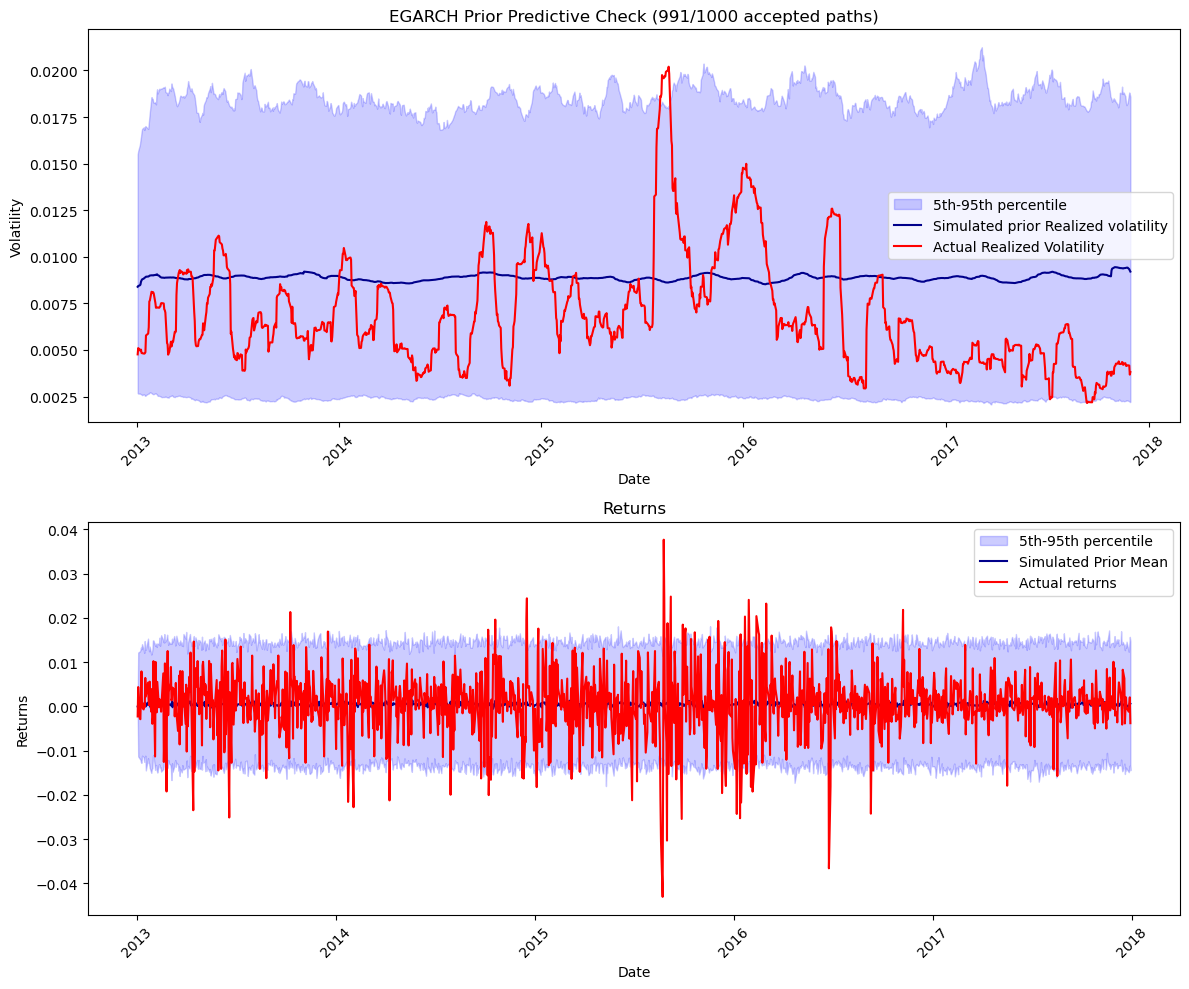

Valid paths: 991/1000 (99%)
Rejection rate indicates prior stationarity constraint tightness


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

omega_egarch = result_egarch.params['omega']
alpha_egarch = result_egarch.params['alpha[1]']  # magnitude
gamma_egarch = result_egarch.params['gamma[1]']  # leverage
beta_egarch  = result_egarch.params['beta[1]']
nu_egarch    = result_egarch.params['nu']
mu_egarch = result_egarch.params['mu']/100 # divide by 100
prior_std = prior_returns_1d.std()
    
import scipy.special

def E_abs_z_t(nu):
    """E[|z|] for standardized t with unit variance"""
    return (2 * np.sqrt(nu - 2) * scipy.special.gamma((nu + 1) / 2)) / \
           (np.sqrt(np.pi) * (nu - 1) * scipy.special.gamma(nu / 2))

# EGARCH equation
def simulate_egarch_t(omega, alpha, beta, gamma, nu, mu, n):
    log_sigma2 = np.zeros(n)
    r = np.zeros(n)
    e_abs = E_abs_z_t(nu)
    log_sigma2[0] = omega / (1 - beta)
    
    for t in range(1, n):
        scale = np.sqrt((nu - 2) / nu)
        z = np.random.standard_t(nu) * scale  # unit variance innovation
        r[t] = mu + np.exp(0.5 * log_sigma2[t-1]) * z
        log_sigma2[t] = (omega +
                         beta * log_sigma2[t-1] +
                         gamma * z +
                         alpha * (np.abs(z) - e_abs))
    
    return r, np.sqrt(np.exp(log_sigma2))

# Prior predictive simulation
np.random.seed(42)
n_paths = 1000
n = len(prior_returns_1d)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

valid_paths = 0
vol = []
rt = []
for _ in range(n_paths):  
    alpha = stats.truncnorm.rvs(
    (0 - alpha_egarch) / 0.05,  # a
    np.inf,                       # b — no upper bound
    loc=alpha_egarch, 
    scale=0.05)   # magnitude, positive
    beta = np.random.beta(47,3)   # used this for volatility persistence         
    gamma = np.random.normal(gamma_egarch, 0.05)     #  expect negative
    mu = np.random.normal(mu_egarch, 0.001)
    nu = 2.1+np.random.gamma(shape = (nu_egarch-2.1)/2, scale=2) # fatter tails
    uncond_vol = stats.truncnorm.rvs(
        (0 - prior_std) / 0.003,
        (0.02 - prior_std) / 0.003,
        loc=prior_std, scale=0.003)
    omega = np.log(uncond_vol**2)*(1-beta)
    
    # Stationarity check: 
    if np.abs(beta) >= 1:
        continue
    r, sigma = simulate_egarch_t(omega, alpha, beta, gamma, nu, mu, n)
    
    #Reject explosive paths
     # this is ok as it happens in MCMC automatically anyway
    if np.any(np.isnan(r)) or np.any(np.isinf(r)) or np.max(np.abs(r)) > 0.5:
        continue
    valid_paths += 1
    vol.append(sigma)
    rt.append(r)
print(len(vol))
print(len(rt))

# use this to excluse things that use newer values
rv_prior_1d_strict      = rv_prior_1d[:-21]
vol_rv = sigma_to_rv_vectorized(np.array(vol),h=21)
prior_vol_rv_dates = prior_dates[:vol_rv.shape[1]]
prior_ret_dates = prior_dates[:len(prior_returns_1d)]

lower = np.percentile(vol_rv, 5,  axis=0)
upper = np.percentile(vol_rv, 95, axis=0)
mean  = np.mean(vol_rv, axis=0)

# use prior_vol_rv_dates instead
axes[0].fill_between(prior_vol_rv_dates, lower, upper,
                     alpha=0.2, color="blue",
                     label="5th-95th percentile")
axes[0].plot(prior_vol_rv_dates, mean, color="darkblue",
             linewidth=1.5, label="Mean of Simulated Prior Realized volatility")
axes[0].plot(prior_vol_rv_dates, rv_prior_1d_strict, color="red",
             linewidth=1.5, label="Actual Realized Volatility")

lower = np.percentile(rt, 5,  axis=0)
upper = np.percentile(rt, 95, axis=0)
mean  = np.mean(rt, axis=0)

axes[1].fill_between(prior_ret_dates, lower, upper,
                     alpha=0.2, color="blue",
                     label="5th-95th percentile")
axes[1].plot(prior_ret_dates, mean, color="darkblue",
             linewidth=1.5, label="Simulated Prior Mean")
axes[1].plot(prior_ret_dates[:len(prior_returns_1d)], prior_returns_1d, color="red",
             linewidth=1.5, label="Actual log returns")

axes[0].set_title(f"EGARCH Prior Predictive Check Volatility: ({valid_paths}/{n_paths} accepted paths)")
axes[0].set_ylabel("Realized Volatility")
axes[0].set_xlabel("Date")
axes[1].set_title("Log Returns")
axes[1].set_ylabel("Log Returns")
axes[1].set_xlabel("Date")
axes[0].legend()
axes[1].legend()

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("egarch_prior_predictive.pdf", bbox_inches='tight')
plt.show()

print(f"Valid paths: {valid_paths}/{n_paths} ({valid_paths/n_paths*100:.0f}%)")
print(f"Rejection rate indicates prior stationarity constraint tightness")

The plots above are sufficiently good, (even though the confidence intervals don't actually map much onto the actual rolling std, it covers it which is enough for the MCMC)

### Implementation

Use Numpyro for implementation of the MCMC method

In [22]:
pip install numpyro jax

Note: you may need to restart the kernel to use updated packages.


This grid is a way to avoid approximations by precomputing potential values, this helps with the numpry sampling. Note that certain values clipped during sampling to avoid unreasonably small/large values to help the MCMC

In [23]:
nu_grid = np.linspace(2.1,100, 1000)
e_abs_grid = E_abs_z_t(nu_grid)

### Regression Code

In [24]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax
jax.config.update("jax_enable_x64", True)  # MUST be before any JAX operations
import jax.numpy as jnp
import numpyro
numpyro.set_host_device_count(4)
returns_jax = jnp.array(regression_returns_1d)  
def egarch_model(returns):
    mu_ret     = numpyro.sample("mu_ret",     dist.Normal(mu_egarch, 0.001))
    alpha      = numpyro.sample("alpha",      dist.TruncatedNormal(alpha_egarch, 0.05, low=0))
    beta       = numpyro.sample("beta",       dist.Beta(47, 3))
    gamma      = numpyro.sample("gamma",      dist.Normal(gamma_egarch, 0.05))
    nu_shift   = numpyro.sample("nu_shift",   dist.Gamma((nu_egarch-2.1)/2, 0.5))
    nu         = nu_shift + 2.1
    uncond_vol = numpyro.sample("uncond_vol", dist.TruncatedNormal(
                                    prior_std, 0.003, low=0, high=0.02))
    omega      = jnp.log(uncond_vol**2) * (1 - beta_egarch)  # jnp + fixed beta (can't use beta as otherwise divergences occurs)

    e_abs_grid_t = jnp.array(e_abs_grid)
    def E_abs_z_interp(nu):
        idx      = (nu - 2.1) / (100 - 2.1) * 999
        idx_low  = jnp.clip(jnp.floor(idx).astype(int), 0, 998)
        idx_high = jnp.clip(idx_low + 1, 0, 999)
        frac     = idx - jnp.floor(idx)
        return e_abs_grid_t[idx_low] * (1-frac) + e_abs_grid_t[idx_high] * frac

    e_abs = E_abs_z_interp(nu)

    def egarch_step(ls2, r):
        z       = (r - mu_ret) / jnp.sqrt(jnp.exp(jnp.clip(ls2, -20.0, 2.0)))
        ls2_new = omega + beta*ls2 + gamma*z + alpha*(jnp.abs(z) - e_abs)
        return jnp.clip(ls2_new, -20.0, 2.0), ls2_new
        
    ls2_init = jnp.float64(np.log(prior_std**2))
    
    _, log_sigma2 = jax.lax.scan(egarch_step, ls2_init, returns[:-1])
    # log_sigma2 shape: (T-1,) — σ_1...σ_{T-1}
    
    # Prepend σ_0
    log_sigma2_full = jnp.concatenate([ls2_init.reshape(1), log_sigma2])
    # log_sigma2_full shape: (T,) — σ_0...σ_{T-1}

    sigma = jnp.sqrt(jnp.exp(log_sigma2_full))
    scale = jnp.clip(sigma * jnp.sqrt((nu-2)/nu), 1e-6, 10)
    
    # Now use full returns — all T observations
    numpyro.sample("obs", dist.StudentT(nu, mu_ret, scale), obs=returns)
    #                                                               not returns[1:]
# Run MCMC
nuts_kernel = NUTS(egarch_model, target_accept_prob=0.95)
mcmc_egarch= MCMC(NUTS(egarch_model, target_accept_prob=0.95),
            num_warmup=2000,
            num_samples=2000,
            num_chains=4,
            chain_method='parallel')
mcmc_egarch.run(jax.random.PRNGKey(42), returns_jax)
mcmc_egarch.print_summary()

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.25      0.03      0.25      0.20      0.30   5745.99      1.00
        beta      0.94      0.00      0.94      0.93      0.95   3647.25      1.00
       gamma     -0.22      0.02     -0.22     -0.26     -0.19   5300.90      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   8209.27      1.00
    nu_shift      3.96      0.96      3.84      2.47      5.47   5807.25      1.00
  uncond_vol      0.01      0.00      0.01      0.00      0.01   3682.01      1.00

Number of divergences: 0


Save data

In [28]:
samples_egarch = mcmc_egarch.get_samples()

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       0.247  0.030   0.192    0.303      0.000    0.000    5747.0   
beta        0.940  0.004   0.933    0.947      0.000    0.000    3741.0   
gamma      -0.224  0.023  -0.267   -0.179      0.000    0.000    5314.0   
nu_shift    3.964  0.964   2.295    5.783      0.013    0.015    6061.0   
uncond_vol  0.009  0.003   0.004    0.014      0.000    0.000    3668.0   
mu_ret      0.001  0.000   0.001    0.001      0.000    0.000    8227.0   

            ess_tail  r_hat  
alpha         5072.0    1.0  
beta          3808.0    1.0  
gamma         4891.0    1.0  
nu_shift      4868.0    1.0  
uncond_vol    3995.0    1.0  
mu_ret        6213.0    1.0  

uncond_vol posterior mean:   0.009057
uncond_vol posterior median: 0.008981
prior_std:                   0.007444
regression_returns std:      0.013171

omega implied mean:   -0.572451
omega implied median: -0.568327

Saved successfully


Here, the volatility estimates are obtained

In [264]:
S = len(samples_egarch["alpha"])
T = len(regression_returns_1d)
# get all parameter values
alpha_all = np.array(samples_egarch["alpha"])
beta_all  = np.array(samples_egarch["beta"])
gamma_all = np.array(samples_egarch["gamma"])
nu_all    = np.array(samples_egarch["nu_shift"]) + 2.1
uncond_all = np.array(samples_egarch["uncond_vol"])   # direct from model
omega_all = np.log(uncond_all**2)*(1-beta_egarch)
mu_all    = np.array(samples_egarch["mu_ret"])    # add mu
e_abs_all = np.array([E_abs_z_t(nu) for nu in nu_all])

# initialize lnsigma squared
ls2_init = np.log(prior_std**2)
ls2 = np.full(S, ls2_init)
sigma_posterior_egarch = np.zeros((S,T))
sigma_posterior_egarch[:,0] = np.sqrt(np.exp(ls2))

# exclude last return and we use time t to find stuff at t+1
for t, r in enumerate(regression_returns_1d[:-1]):
    z   = (r - mu_all) / np.sqrt(np.exp(np.clip(ls2, -20, 2)))  # subtract mu
    ls2 = np.clip(omega_all + beta_all*ls2 + gamma_all*z +
        alpha_all*(np.abs(z) - e_abs_all),
        -20, 2)
    sigma_posterior_egarch[:, t+1] = np.sqrt(np.exp(ls2))

sigma_mean  = sigma_posterior_egarch.mean(axis=0)
sigma_lower = np.percentile(sigma_posterior_egarch, 5,  axis=0)
sigma_upper = np.percentile(sigma_posterior_egarch, 95, axis=0)
print(f"sigma_posterior shape: {sigma_posterior_egarch.shape}")  # (S, T)

sigma_posterior shape: (8000, 1008)


Check if values make sense, the first value should be similar

In [265]:
sigma_posterior_rv_egarch = sigma_to_rv_vectorized(sigma_posterior_egarch, h=21)
n = sigma_posterior_rv_egarch.shape[1]

rv_actual_egarch = rv_regression_1d[:n]  # take first 986 observations
rv_mean_egarch   = sigma_posterior_rv_egarch.mean(axis=0)
print(n)
print(f"rv_actual[:5]:  {rv_actual_egarch[:5]}")
print(f"rv_mean[:5]:    {rv_mean_egarch[:5]}")
print(f"rv_actual[100]: {rv_actual_egarch[100]:.6f}")
print(f"rv_mean[100]:   {rv_mean_egarch[100]:.6f}")


987
rv_actual[:5]:  [0.00540532 0.00747145 0.01204286 0.0127758  0.01280081]
rv_mean[:5]:    [0.00567247 0.00570278 0.0057511  0.00640415 0.00849548]
rv_actual[100]: 0.006413
rv_mean[100]:   0.007032


The realized volatility plot for the 90% credible intervals for EGARCH

Measurement noise std: 0.2007
Coverage (with noise): 85.92%
COVID start: 2020-01-30 (obs 522)
COVID end:   2020-04-30 (obs 585)
Pre-COVID coverage:  81.42%
COVID coverage:      87.30%
Post-COVID coverage: 91.54%


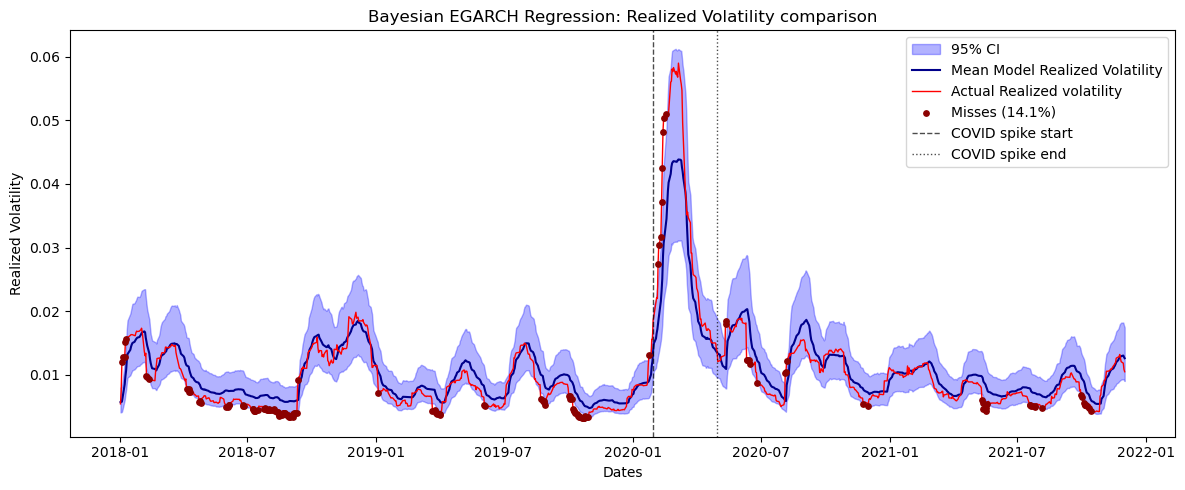

In [266]:
# Coverage with measurement noise
sigma_eta_meas_egarch = np.std(np.log(rv_actual_egarch) - np.log(rv_mean_egarch))
print(f"Measurement noise std: {sigma_eta_meas_egarch:.4f}")

#noise
noise = np.random.normal(0, sigma_eta_meas_egarch, size=sigma_posterior_rv_egarch[:, :n].shape)
sigma_posterior_rv_noisy_egarch = sigma_posterior_rv_egarch[:, :n] * np.exp(noise)

rv_lower_noisy_egarch = np.percentile(sigma_posterior_rv_noisy_egarch, 5,  axis=0)
rv_upper_noisy_egarch = np.percentile(sigma_posterior_rv_noisy_egarch, 95, axis=0)

inside_noisy_egarch   = (rv_actual_egarch >= rv_lower_noisy_egarch) & (rv_actual_egarch <= rv_upper_noisy_egarch)
coverage_noisy_egarch = np.mean(inside_noisy_egarch)
print(f"Coverage (with noise): {coverage_noisy_egarch:.2%}")

# Find COVID index by date instead of threshold
covid_start_date = pd.Timestamp("2020-01-30")  # approximate COVID start
covid_end_date   = pd.Timestamp("2020-04-30")  # approximate COVID end

# Find integer indices corresponding to dates
covid_idx = np.searchsorted(regression_dates, covid_start_date)
covid_end = np.searchsorted(regression_dates, covid_end_date)

print(f"COVID start: {regression_dates[covid_idx].date()} (obs {covid_idx})")
print(f"COVID end:   {regression_dates[covid_end].date()} (obs {covid_end})")

# Pre-COVID
inside_pre_egarch = (rv_actual_egarch[:covid_idx] >= rv_lower_noisy_egarch[:covid_idx]) & \
             (rv_actual_egarch[:covid_idx] <= rv_upper_noisy_egarch[:covid_idx])
print(f"Pre-COVID coverage:  {np.mean(inside_pre_egarch):.2%}")

# COVID period
inside_covid_egarch = (rv_actual_egarch[covid_idx:covid_end] >= rv_lower_noisy_egarch[covid_idx:covid_end]) & \
               (rv_actual_egarch[covid_idx:covid_end] <= rv_upper_noisy_egarch[covid_idx:covid_end])
print(f"COVID coverage:      {np.mean(inside_covid_egarch):.2%}")

# Post-COVID
inside_post_egarch = (rv_actual_egarch[covid_end:n] >= rv_lower_noisy_egarch[covid_end:n]) & \
              (rv_actual_egarch[covid_end:n] <= rv_upper_noisy_egarch[covid_end:n])
print(f"Post-COVID coverage: {np.mean(inside_post_egarch):.2%}")
# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(regression_dates[:n], rv_lower_noisy_egarch, rv_upper_noisy_egarch,
                alpha=0.3, color='blue', label='90% CI')
ax.plot(regression_dates[:n], rv_mean_egarch, color='darkblue', lw=1.5, label='Mean Model Realized Volatility')
ax.plot(regression_dates[:n], rv_actual_egarch, color='red', lw=1, label='Actual Realized volatility')
# Add red dots for misses
miss_idx_egarch = np.where(~inside_noisy_egarch)[0]
miss_dates_egarch = regression_dates[miss_idx_egarch]
ax.scatter(miss_dates_egarch, rv_actual_egarch[miss_idx_egarch],
           color='darkred', s=15, zorder=5, 
           label=f'Misses ({(1-coverage_noisy_egarch)*100:.1f}%)')
ax.axvline(covid_start_date, color='black', linestyle='--', 
           alpha=0.7, lw=1, label='COVID spike start')
ax.axvline(covid_end_date, color='black', linestyle=':', 
           alpha=0.7, lw=1, label='COVID spike end')
ax.set_title("Bayesian EGARCH Regression: Realized Volatility comparison")
ax.set_xlabel("Dates")
ax.set_ylabel("Realized Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("egarch_regression_rv.pdf", bbox_inches='tight')
plt.show()


In [267]:
# Realized volatility Coverage at different CI levels
print("Coverage at different CI levels:")
print("-" * 40)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower = np.percentile(sigma_posterior_rv_noisy_egarch, (100-level)/2, axis=0)
    upper = np.percentile(sigma_posterior_rv_noisy_egarch, 100-(100-level)/2, axis=0)
    inside = (rv_actual_egarch >= lower) & (rv_actual_egarch <= upper)
    print(f"{level}% CI coverage: {np.mean(inside):.2%}")

Coverage at different CI levels:
----------------------------------------
50% CI coverage: 44.48%
60% CI coverage: 53.39%
70% CI coverage: 63.32%
80% CI coverage: 74.87%
85% CI coverage: 81.56%
90% CI coverage: 85.92%
95% CI coverage: 92.50%
99% CI coverage: 97.26%


KS p-value:       0.2347
95% PIT coverage: 95.63%


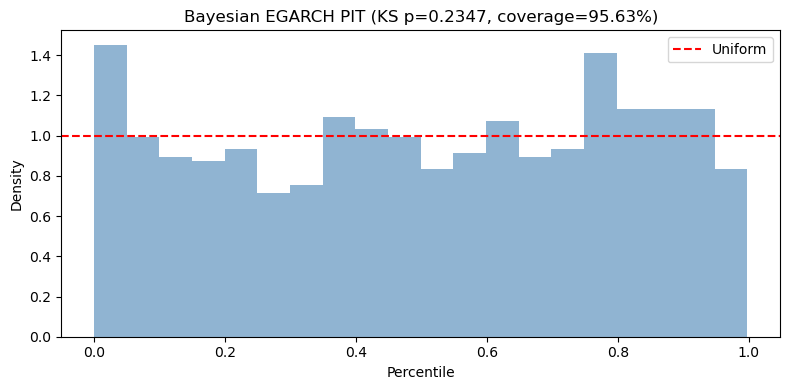

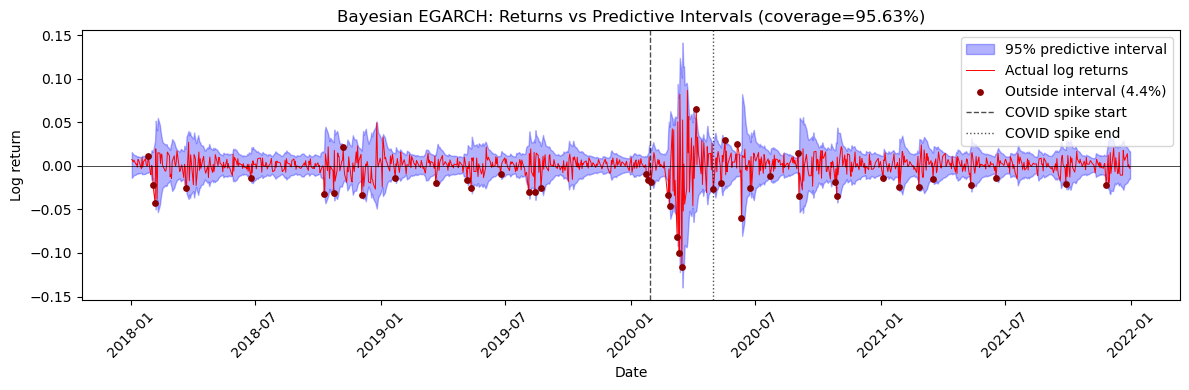

In [269]:
# Return PIT and return coverage
from scipy import stats as scipy_stats

mu_all    = np.array(samples_egarch["mu_ret"])
nu_all    = np.array(samples_egarch["nu_shift"]) + 2.1
scale_all = sigma_posterior_egarch * np.sqrt((nu_all - 2) / nu_all)[:, np.newaxis]

returns_obs = regression_returns_1d
n_pit = min(len(returns_obs), sigma_posterior_egarch.shape[1])

# ── PIT ────────────────────────────────────────────────────────────────
cdf_matrix = scipy_stats.t.cdf(
    returns_obs[:n_pit][np.newaxis, :],
    df=nu_all[:, np.newaxis],
    loc=mu_all[:, np.newaxis],
    scale=scale_all[:, :n_pit]
)
u_egarch = cdf_matrix.mean(axis=0)

ks_stat_egarch, ks_pval_egarch = scipy_stats.kstest(u_egarch, 'uniform')
coverage_pit_egarch = np.mean((u_egarch >= 0.05) & (u_egarch <= 0.95))

print(f"KS p-value:       {ks_pval_egarch:.4f}")
print(f"90% PIT coverage: {coverage_pit_egarch:.2%}")


In [132]:

print("Return coverage at different CI levels (EGARCH):")
print("-" * 40)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower_u = (100 - level) / 200       # e.g. 0.025 for 95%
    upper_u = 1 - (100 - level) / 200   # e.g. 0.975 for 95%
    coverage_l = np.mean((u_egarch >= lower_u) & (u_egarch <= upper_u))
    print(f"{level}% CI coverage: {coverage_l:.2%}")

Return coverage at different CI levels (EGARCH):
----------------------------------------
50% CI coverage: 47.72%
60% CI coverage: 59.13%
70% CI coverage: 69.84%
80% CI coverage: 79.56%
85% CI coverage: 84.92%
90% CI coverage: 89.98%
95% CI coverage: 96.13%
99% CI coverage: 98.91%


### Sequential EGARCH

In [198]:
# Initialization at start of regression
ls2 = np.log(prior_std**2)  # from prior period
# Uses posterior mean parameters
alpha_post = float(np.array(samples_egarch["alpha"]).mean())
beta_post  = float(np.array(samples_egarch["beta"]).mean())
gamma_post = float(np.array(samples_egarch["gamma"]).mean())
nu_post    = float(np.array(samples_egarch["nu_shift"]).mean()) + 2.1
omega_post = np.log(float(np.array(samples_egarch["uncond_vol"]).mean())**2)*(1-beta_egarch)
mu_post    = float(np.array(samples_egarch["mu_ret"]).mean())
e_abs_post = float(E_abs_z_t(nu_post))

print(f"alpha:     {alpha_post:.4f}")
print(f"beta:      {beta_post:.4f}")
print(f"gamma:     {gamma_post:.4f}")
print(f"nu:        {nu_post:.4f}")
print(f"uncond_vol:{uncond_post:.6f}")
print(f"mu_ret:    {mu_post:.6f}")
# Then run recursion through regression
for r in regression_returns_1d:
    z   = (r - mu_post) / np.sqrt(np.exp(np.clip(ls2, -20, 2)))
    ls2 = np.clip(omega_post + beta_egarch*ls2 + 
                  gamma_post*z + alpha_post*(np.abs(z) - e_abs_post),
                  -20, 2)

ls2_carry_egarch = ls2
print(ls2)
print(f"sigma at end of regression: {np.sqrt(np.exp(ls2_carry_egarch)):.6f}")

-9.498206958103815
sigma at end of regression: 0.008659


In [199]:
window_boundaries = pd.date_range(start="2022-01-01",
                                   end="2026-01-01",
                                   freq="6MS")
for i in range(len(window_boundaries)-1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    w = full_returns[window_start:window_end]
    print(f"Window {i+1}: {w.index[0].date()} to {w.index[-1].date()}, n={len(w)}")

total = sum(len(full_returns[window_boundaries[i]:window_boundaries[i+1]-pd.Timedelta(days=1)]) 
            for i in range(len(window_boundaries)-1))
print(f"Total: {total}")
print(f"Sequential: {len(sequential_returns_1d)}")

Window 1: 2022-01-03 to 2022-06-30, n=124
Window 2: 2022-07-01 to 2022-12-30, n=127
Window 3: 2023-01-03 to 2023-06-30, n=124
Window 4: 2023-07-03 to 2023-12-29, n=126
Window 5: 2024-01-02 to 2024-06-28, n=124
Window 6: 2024-07-01 to 2024-12-31, n=128
Window 7: 2025-01-02 to 2025-06-30, n=122
Window 8: 2025-07-01 to 2025-12-30, n=127
Total: 1002
Sequential: 1002


In [200]:
# numpyro uses rate parameterization
# nu_shift ~ Gamma(shape, rate)
# Check against empirical samples
nu_shift_samples = np.array(samples_egarch["nu_shift"])
shape, rate = fit_gamma_params(nu_shift_samples)

print(f"Fitted shape: {shape:.4f}")
print(f"Fitted rate:  {rate:.4f}")

# Verify — mean should match
print(f"Implied mean: {shape/rate:.4f}")
print(f"Sample mean:  {nu_shift_samples.mean():.4f}")

# Verify — variance should match  
print(f"Implied var:  {shape/rate**2:.4f}")
print(f"Sample var:   {nu_shift_samples.var():.4f}")

Fitted shape: 16.9275
Fitted rate:  4.2701
Implied mean: 3.9642
Sample mean:  3.9642
Implied var:  0.9284
Sample var:   0.9284


In [201]:
from scipy.stats import beta as beta_dist
from scipy.optimize import minimize

def fit_beta_params(samples):
    """Fit Beta distribution to posterior samples — for beta parameter"""
    a, b, _, _ = beta_dist.fit(np.array(samples), floc=0, fscale=1)
    return float(a), float(b)

def fit_gamma_params(samples):
    """Fit Gamma distribution to posterior samples — for nu_shift"""
    from scipy.stats import gamma as gamma_dist
    # Method of moments
    mu  = np.array(samples).mean()
    var = np.array(samples).var()
    # shape = mu^2/var, rate = mu/var
    shape = mu**2 / var
    rate  = mu / var
    return float(shape), float(rate)

# ── Initialize with regression posterior ──────────────────────────────
samples_w = samples_egarch  # regression posterior

# ── Window loop ────────────────────────────────────────────────────────
all_pit_values_egarch_seq  = []
all_vol_egarch_seq     = []
all_returns_obs_egarch_seq = []
all_window_stats_egarch_seq = []
ls2_current_seq       = ls2_carry_egarch

# Extract initial posterior mean parameters
alpha_post_seq = float(np.array(samples_egarch["alpha"]).mean())
beta_post_seq  = float(np.array(samples_egarch["beta"]).mean())
gamma_post_seq = float(np.array(samples_egarch["gamma"]).mean())
nu_post_seq    = float(np.array(samples_egarch["nu_shift"]).mean()) + 2.1
uncond_post_seq = float(np.array(samples_egarch["uncond_vol"]).mean())
omega_post_seq  = np.log(uncond_post_seq**2) * (1 - beta_egarch)
mu_post_seq    = float(np.array(samples_egarch["mu_ret"]).mean())
e_abs_post_seq = float(E_abs_z_t(nu_post_seq))
scale_factor_seq = np.sqrt((nu_post_seq - 2) / nu_post_seq)

for i in range(len(window_boundaries)-1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_returns = full_returns[window_start:window_end].values.flatten().astype('float64')
    window_rv      = full_rv[window_start:window_end].dropna().values.flatten()

    # ── Step 1: Sequential evaluation ─────────────────────────────────
    T_w   = len(window_returns)
    vol_w = np.zeros(T_w)
    pit_w = np.zeros(T_w)
    ls2   = ls2_current_seq
    # get the volatility values here
    for t, r_t in enumerate(window_returns):
        sigma_t  = np.sqrt(np.exp(np.clip(ls2, -20, 2)))
        scale_t  = sigma_t * scale_factor_seq
        pit_w[t] = scipy_stats.t.cdf(r_t, df=nu_post_seq, loc=mu_post_seq, scale=scale_t)
        vol_w[t] = sigma_t
        z   = (r_t - mu_post_seq) / sigma_t
        ls2 = np.clip(omega_post_seq + beta_post_seq*ls2 + gamma_post_seq*z +
                      alpha_post_seq*(np.abs(z) - e_abs_post_seq), -20, 2)

    all_pit_values_egarch_seq.extend(pit_w)
    all_vol_egarch_seq.extend(vol_w)
    all_returns_obs_egarch_seq.extend(window_returns)

    # ── Step 2: Extract priors from previous posterior ─────────────────
    alpha_prior_mu  = float(np.array(samples_w["alpha"]).mean())
    alpha_prior_std = max(float(np.array(samples_w["alpha"]).std()), 0.01)
    beta_a, beta_b  = fit_beta_params(samples_w["beta"])
    gamma_prior_mu  = float(np.array(samples_w["gamma"]).mean())
    gamma_prior_std = max(float(np.array(samples_w["gamma"]).std()), 0.01)
    uncond_prior_mu  = float(np.array(samples_w["uncond_vol"]).mean())
    uncond_prior_std = max(float(np.array(samples_w["uncond_vol"]).std()), 0.003)
    mu_prior_mu     = float(np.array(samples_w["mu_ret"]).mean())
    mu_prior_std    = max(float(np.array(samples_w["mu_ret"]).std()), 0.0001)
    nu_shape, nu_rate = fit_gamma_params(samples_w["nu_shift"])

    # ── Step 3: Refit on new window only with updated priors ───────────
    returns_jax_w = jnp.array(window_returns)

    def egarch_model_updated(returns):
        mu_ret   = numpyro.sample("mu_ret",   dist.Normal(mu_prior_mu, mu_prior_std))
        alpha    = numpyro.sample("alpha",    dist.TruncatedNormal(
                                                alpha_prior_mu, alpha_prior_std, low=0))
        beta     = numpyro.sample("beta",     dist.Beta(beta_a, beta_b))
        gamma    = numpyro.sample("gamma",    dist.Normal(gamma_prior_mu, gamma_prior_std))
        nu_shift = numpyro.sample("nu_shift", dist.Gamma(nu_shape, nu_rate))
        nu       = nu_shift + 2.1
        uncond_vol = numpyro.sample("uncond_vol", dist.TruncatedNormal(uncond_prior_mu, uncond_prior_std, low=0, high=0.03))
        omega    = jnp.log(uncond_vol**2)*(1-beta_egarch)

        e_abs_grid_t = jnp.array(e_abs_grid)
        def E_abs_z_interp(nu):
            idx      = (nu - 2.1) / (100 - 2.1) * 999
            idx_low  = jnp.clip(jnp.floor(idx).astype(int), 0, 998)
            idx_high = jnp.clip(idx_low + 1, 0, 999)
            frac     = idx - jnp.floor(idx)
            return e_abs_grid_t[idx_low] * (1-frac) + e_abs_grid_t[idx_high] * frac

        e_abs = E_abs_z_interp(nu)

        def egarch_step(ls2, r):
            z       = (r - mu_ret) / jnp.sqrt(jnp.exp(jnp.clip(ls2, -20.0, 2.0)))
            ls2_new = omega + beta*ls2 + gamma*z + alpha*(jnp.abs(z) - e_abs)
            return jnp.clip(ls2_new, -20.0, 2.0), ls2_new
        ls2_init = jnp.float64(ls2_current_seq)
        _, log_sigma2 = jax.lax.scan(egarch_step, ls2_init, returns[:-1])
        log_sigma2_full = jnp.concatenate([ls2_init.reshape(1), log_sigma2])
        sigma = jnp.sqrt(jnp.exp(log_sigma2_full))
        scale = jnp.clip(sigma * jnp.sqrt((nu-2)/nu), 1e-6, 10)
        numpyro.sample("obs", dist.StudentT(nu, mu_ret, scale), obs=returns)

    print(f"Refitting on {len(window_returns)} observations...")
    mcmc_w = MCMC(NUTS(egarch_model_updated, target_accept_prob=0.95),
                  num_warmup=500, num_samples=1000, num_chains=2, chain_method="sequential")
    mcmc_w.run(jax.random.PRNGKey(i+100), returns_jax_w)
    mcmc_w.print_summary()
    samples_w = mcmc_w.get_samples()

    # ── Step 4: Update parameters for next window ──────────────────────
    alpha_post_seq   = float(np.array(samples_w["alpha"]).mean())
    beta_post_seq    = float(np.array(samples_w["beta"]).mean())
    gamma_post_seq   = float(np.array(samples_w["gamma"]).mean())
    nu_post_seq      = float(np.array(samples_w["nu_shift"]).mean()) + 2.1
    uncond_post_seq   = float(np.array(samples_w["uncond_vol"]).mean())
    mu_post_seq      = float(np.array(samples_w["mu_ret"]).mean())
    e_abs_post_seq   = float(E_abs_z_t(nu_post_seq))
    scale_factor_seq = np.sqrt((nu_post_seq - 2) / nu_post_seq)

    beta_egarch_seq = beta_post_seq
    omega_post_seq = np.log(uncond_post_seq**2)*(1-beta_egarch_seq)

    all_window_stats_egarch_seq.append({
    "window":       i+1,
    "start":        str(window_start.date()),
    "end":          str(window_end.date()),
    "n_obs":        len(window_returns),
    "pit_coverage": float(np.mean((pit_w >= 0.05) & (pit_w <= 0.95))),
    "uncond_vol":   float(np.array(samples_w["uncond_vol"]).mean()),
    "beta":         float(np.array(samples_w["beta"]).mean())
    })
    print(f"Window {i+1} PIT coverage: {all_window_stats_egarch_seq[-1]['pit_coverage']:.2%}")
    # ── Step 5: Update noise estimate ─────────────────────────────────
    ls2_current_seq = ls2
    print(f"Carry forward sigma: {np.sqrt(np.exp(ls2_current_seq)):.6f}")

# ── Final evaluation ───────────────────────────────────────────────────
all_pit_values_egarch_seq  = np.array(all_pit_values_egarch_seq)
all_vol_egarch_seq     = np.array(all_vol_egarch_seq)
all_returns_obs_egarch_seq = np.array(all_returns_obs_egarch_seq)
print(f"Total obs:      {len(all_pit_values_egarch_seq)}")



Refitting on 124 observations...


sample: 100%|█████████████████████████| 1500/1500 [00:11<00:00, 127.28it/s, 127 steps of size 3.89e-02. acc. prob=0.95]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.24      0.03      0.24      0.19      0.28   1382.80      1.00
        beta      0.94      0.00      0.94      0.93      0.94    958.87      1.00
       gamma     -0.22      0.02     -0.22     -0.25     -0.18   1534.96      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   1787.31      1.00
    nu_shift      4.41      0.98      4.32      2.79      5.89   1527.57      1.00
  uncond_vol      0.01      0.00      0.01      0.01      0.02   1014.14      1.00

Number of divergences: 0
Window 1 PIT coverage: 94.35%
Updated noise std: 0.0646
Carry forward sigma: 0.017220
Refitting on 127 observations...


sample: 100%|██████████████████████████| 1500/1500 [00:15<00:00, 97.45it/s, 127 steps of size 4.18e-02. acc. prob=0.94]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.22      0.03      0.22      0.18      0.28   1452.56      1.00
        beta      0.94      0.00      0.94      0.93      0.94   1235.78      1.00
       gamma     -0.21      0.02     -0.21     -0.25     -0.18   1715.17      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   2054.37      1.00
    nu_shift      4.42      0.95      4.38      2.83      5.93   1372.02      1.00
  uncond_vol      0.01      0.00      0.01      0.01      0.02   1194.96      1.00

Number of divergences: 0
Window 2 PIT coverage: 94.49%
Updated noise std: 0.1255
Carry forward sigma: 0.014713
Refitting on 124 observations...


...


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.20      0.03      0.20      0.16      0.24   1480.25      1.00
        beta      0.94      0.00      0.94      0.94      0.94   1189.95      1.00
       gamma     -0.21      0.02     -0.21     -0.24     -0.18   1372.56      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   1656.47      1.00
    nu_shift      4.41      0.86      4.35      3.07      5.81   1413.80      1.00
  uncond_vol      0.01      0.00      0.01      0.01      0.01   1219.90      1.00

Number of divergences: 0
Window 6 PIT coverage: 92.97%
Updated noise std: 0.1441
Carry forward sigma: 0.012666
Refitting on 122 observations...


sample: 100%|█████████████████████████| 1500/1500 [00:11<00:00, 131.07it/s, 127 steps of size 2.66e-02. acc. prob=0.96]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.20      0.02      0.20      0.16      0.24   1851.75      1.00
        beta      0.94      0.00      0.94      0.94      0.94   1287.11      1.00
       gamma     -0.21      0.02     -0.21     -0.24     -0.18   1392.40      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   1851.75      1.00
    nu_shift      4.22      0.81      4.18      2.89      5.45   1469.37      1.00
  uncond_vol      0.01      0.00      0.01      0.01      0.01   1210.57      1.00

Number of divergences: 0
Window 7 PIT coverage: 94.26%
Updated noise std: 0.2325
Carry forward sigma: 0.006321
Refitting on 127 observations...


sample: 100%|█████████████████████████| 1500/1500 [00:13<00:00, 112.22it/s, 127 steps of size 3.01e-02. acc. prob=0.95]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.19      0.02      0.19      0.15      0.23   1227.72      1.00
        beta      0.94      0.00      0.94      0.94      0.94   1308.79      1.00
       gamma     -0.21      0.02     -0.21     -0.24     -0.18   1556.67      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   2014.71      1.00
    nu_shift      4.04      0.76      3.99      2.77      5.25   1773.85      1.00
  uncond_vol      0.01      0.00      0.01      0.00      0.01   1282.98      1.00

Number of divergences: 0
Window 8 PIT coverage: 97.64%
Updated noise std: 0.1546
Carry forward sigma: 0.006576

Final Sequential Results:
PIT KS p-value: 0.1411
PIT coverage:   96.01%
Total obs:      1002


In [217]:
ks_stat_egarch_seq, ks_pval_egarch_seq = scipy_stats.kstest(all_pit_values_egarch_seq, 'uniform')
coverage_pit_egarch_seq     = np.mean((all_pit_values_egarch_seq >= 0.05) & (all_pit_values_egarch_seq <= 0.95))
print(f"\nFinal Sequential Results:")
print(f"PIT KS p-value: {ks_pval_egarch_seq:.4f}")
print(f"PIT coverage:   {coverage_pit_egarch_seq:.2%}")
print(f"Total obs:      {len(all_pit_values_egarch_seq)}")


Final Sequential Results:
PIT KS p-value: 0.1411
PIT coverage:   96.01%
Total obs:      1002


Different return coverages

In [215]:
# Overall
print("EGARCH Sequential Return Coverage at different CI levels:")
print("-" * 40)
all_pit_egarch_seq = np.array(all_pit_values_egarch_seq)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower_u = (100 - level) / 200
    upper_u = 1 - (100 - level) / 200
    coverage_l = np.mean((all_pit_egarch_seq >= lower_u) & 
                          (all_pit_egarch_seq <= upper_u))
    print(f"{level}% CI coverage: {coverage_l:.2%}")

# Per window
print("\nPer window PIT coverage:")
cumulative = 0
for stat in all_window_stats_egarch_seq:
    n_w   = stat['n_obs']
    pit_w = all_pit_egarch_seq[cumulative:cumulative+n_w]
    cov_w = np.mean((pit_w >= 0.05) & (pit_w <= 0.95))
    print(f"Window {stat['window']} ({stat['start']} to {stat['end']}): "
          f"{cov_w:.2%}")
    cumulative += n_w

EGARCH Sequential Return Coverage at different CI levels:
----------------------------------------
50% CI coverage: 51.00%
60% CI coverage: 61.68%
70% CI coverage: 71.16%
80% CI coverage: 81.64%
85% CI coverage: 86.83%
90% CI coverage: 91.82%
95% CI coverage: 96.01%
99% CI coverage: 99.10%

Per window PIT coverage:
Window 1 (2022-01-01 to 2022-06-30): 94.35%
Window 2 (2022-07-01 to 2022-12-31): 94.49%
Window 3 (2023-01-01 to 2023-06-30): 99.19%
Window 4 (2023-07-01 to 2023-12-31): 97.62%
Window 5 (2024-01-01 to 2024-06-30): 97.58%
Window 6 (2024-07-01 to 2024-12-31): 92.97%
Window 7 (2025-01-01 to 2025-06-30): 94.26%
Window 8 (2025-07-01 to 2025-12-31): 97.64%


In [ ]:
Noise estimates are computed here

In [240]:
# ── Initialize with regression residuals ───────────────────────────────
all_log_resid_egarch = list(
    np.log(rv_actual_egarch) - np.log(rv_mean_egarch))

print(f"Regression noise: {np.std(all_log_resid_egarch):.4f}")

# ── Accumulate window residuals ────────────────────────────────────────
noise_running_egarch = [np.std(all_log_resid_egarch)]  # window 0 = regression

cumulative = 0
for j, stat in enumerate(all_window_stats_egarch):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, len(seq_vol_rv_egarch))
    n_valid = min(end_idx - cumulative, 
                  len(rv_sequential_1d) - cumulative)
    
    if n_valid > 21:
        rv_w   = rv_sequential_1d[cumulative:cumulative+n_valid]
        vol_w  = seq_vol_rv_egarch[cumulative:cumulative+n_valid]
        
        # Add this window's residuals
        log_resid_w = np.log(rv_w) - np.log(vol_w)
        all_log_resid_egarch.extend(log_resid_w)
    
    # Running std after this window
    noise_running_egarch.append(np.std(all_log_resid_egarch))
    
    print(f"Window {j+1}: n_total={len(all_log_resid_egarch)}, "
          f"noise={noise_running_egarch[-1]:.4f}")
    
    cumulative += n_w

print(f"\nNoise history: {[f'{n:.4f}' for n in noise_running_egarch]}")

Regression noise: 0.2052
Window 1: n_total=1111, noise=0.1970
Window 2: n_total=1238, noise=0.1927
Window 3: n_total=1362, noise=0.1926
Window 4: n_total=1488, noise=0.1925
Window 5: n_total=1612, noise=0.1898
Window 6: n_total=1740, noise=0.1879
Window 7: n_total=1862, noise=0.1942
Window 8: n_total=1968, noise=0.1944

Noise history: ['0.2052', '0.1970', '0.1927', '0.1926', '0.1925', '0.1898', '0.1879', '0.1942', '0.1944']


In [241]:
# noise_running_egarch[0] = regression noise
# noise_running_egarch[1] = after window 1
# noise_running_egarch[i] = applied to window i+1
# realized volatility
seq_vol_rv_egarch = sigma_to_rv_vectorized(
    np.array(all_vol_egarch_seq).reshape(1, -1), h=21
).flatten()
vol_noisy_combined = np.zeros((200, len(seq_vol_rv_egarch)))
cumulative = 0

for j, stat in enumerate(all_window_stats_egarch):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, len(seq_vol_rv_egarch))
    n_valid = end_idx - cumulative
    
    if cumulative >= len(seq_vol_rv_egarch):
        break
    
    # Use noise from BEFORE this window — no look-ahead
    noise_w = noise_running_egarch[j]  # index j = after window j-1
    
    noise_sim = np.random.normal(0, noise_w, size=(200, n_valid))
    vol_noisy_combined[:, cumulative:end_idx] = \
        seq_vol_rv_egarch[cumulative:end_idx].reshape(1,-1) * np.exp(noise_sim)
    
    cumulative += n_w

In [242]:
# ── CI bands at different levels ───────────────────────────────────────
rv_lower_seq_egarch = np.percentile(vol_noisy_combined, 5,  axis=0)
rv_upper_seq_egarch = np.percentile(vol_noisy_combined, 95, axis=0)

n_rv_seq_egarch = min(len(rv_sequential_1d), len(seq_vol_rv_egarch))

# Coverage at different levels
print("\nCoverage at different CI levels:")
print("-" * 40)
for level in [80, 85, 90, 95, 99]:
    lower_l = np.percentile(vol_noisy_combined, (100-level)/2, axis=0)
    upper_l = np.percentile(vol_noisy_combined, 100-(100-level)/2, axis=0)
    inside_l = (rv_sequential_1d[:n_rv_seq_egarch] >= lower_l[:n_rv_seq_egarch]) & \
               (rv_sequential_1d[:n_rv_seq_egarch] <= upper_l[:n_rv_seq_egarch])
    print(f"{level}% CI coverage: {np.mean(inside_l):.2%}")

# Main coverage
inside_rv_seq_egarch   = (rv_sequential_1d[:n_rv_seq_egarch] >=
                          rv_lower_seq_egarch[:n_rv_seq_egarch]) & \
                         (rv_sequential_1d[:n_rv_seq_egarch] <=
                          rv_upper_seq_egarch[:n_rv_seq_egarch])
coverage_rv_seq_egarch = np.mean(inside_rv_seq_egarch)
print(f"\nMain 90% CI coverage: {coverage_rv_seq_egarch:.2%}")

# Per window breakdown
print("\nPer window breakdown:")
cumulative = 0
for j, stat in enumerate(all_window_stats_egarch):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, n_rv_seq_egarch)
    if cumulative >= n_rv_seq_egarch:
        print(f"Window {stat['window']}: no RV data")
        cumulative += n_w
        continue
    rv_w    = rv_sequential_1d[cumulative:end_idx]
    lower_w = rv_lower_seq_egarch[cumulative:end_idx]
    upper_w = rv_upper_seq_egarch[cumulative:end_idx]
    n_valid = min(len(rv_w), len(lower_w))
    if n_valid == 0:
        cumulative += n_w
        continue
    inside_w = (rv_w[:n_valid] >= lower_w[:n_valid]) & \
               (rv_w[:n_valid] <= upper_w[:n_valid])
    print(f"Window {stat['window']} ({stat['start']} to {stat['end']}): "
          f"RV={np.mean(inside_w):.2%}, "
          f"noise={noise_running_egarch[j]:.4f}, "
          f"ratio={rv_w.mean()/seq_vol_rv_egarch[cumulative:end_idx].mean():.3f}")
    cumulative += n_w


Coverage at different CI levels:
----------------------------------------
80% CI coverage: 62.18%
85% CI coverage: 68.20%
90% CI coverage: 75.23%
95% CI coverage: 85.63%
99% CI coverage: 94.90%

Main 90% CI coverage: 75.23%

Per window breakdown:
Window 1 (2022-01-01 to 2022-06-30): RV=100.00%, noise=0.2052, ratio=0.954
Window 2 (2022-07-01 to 2022-12-31): RV=95.28%, noise=0.1970, ratio=0.919
Window 3 (2023-01-01 to 2023-06-30): RV=50.00%, noise=0.1927, ratio=0.748
Window 4 (2023-07-01 to 2023-12-31): RV=46.83%, noise=0.1926, ratio=0.729
Window 5 (2024-01-01 to 2024-06-30): RV=79.84%, noise=0.1925, ratio=0.828
Window 6 (2024-07-01 to 2024-12-31): RV=92.19%, noise=0.1898, ratio=0.936
Window 7 (2025-01-01 to 2025-06-30): RV=72.95%, noise=0.1879, ratio=1.057
Window 8 (2025-07-01 to 2025-12-31): RV=62.26%, noise=0.1942, ratio=0.801


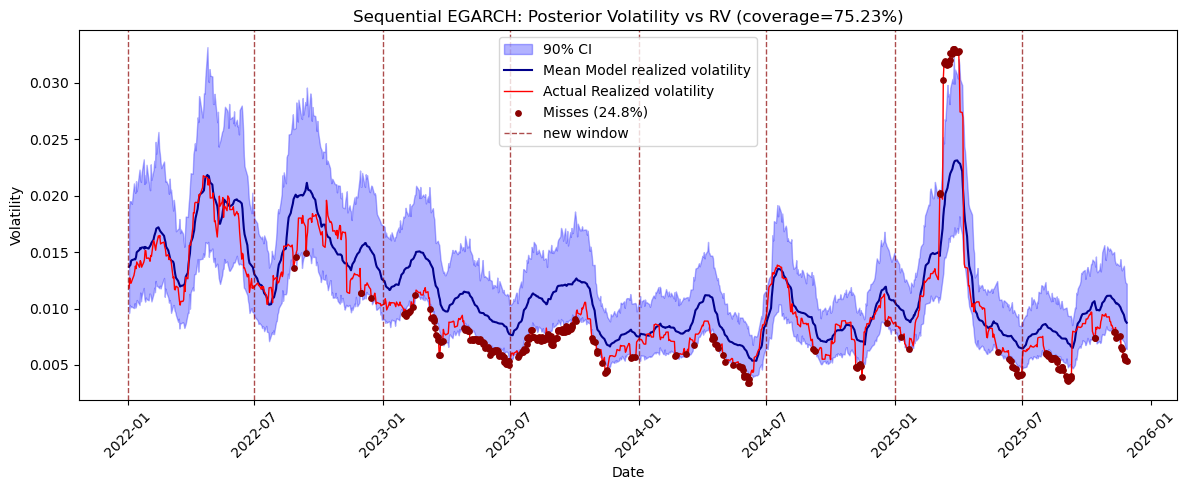

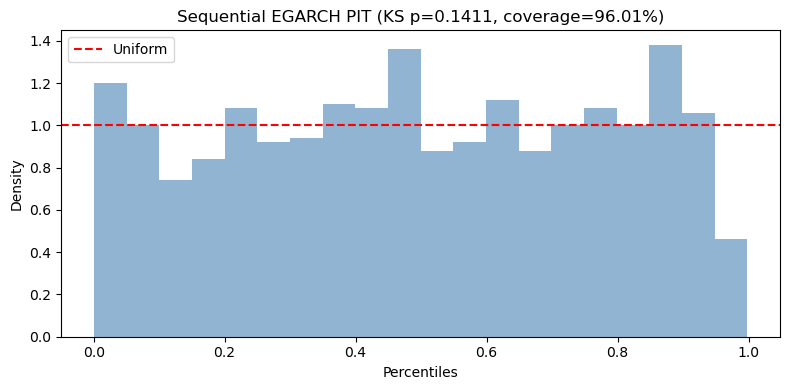

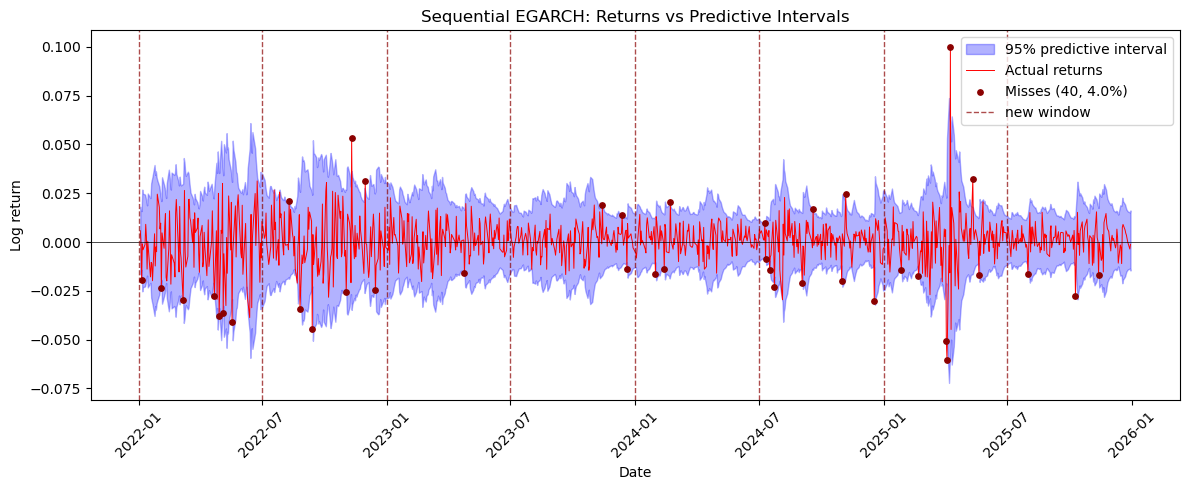

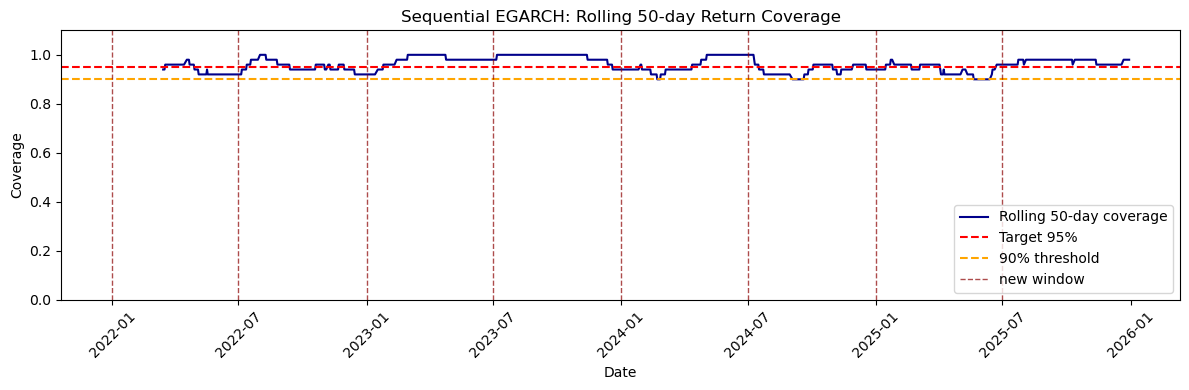

In [257]:
# ── Sequential EGARCH dates ────────────────────────────────────────────
seq_dates     = sequential_returns.index[:len(all_returns_obs_egarch)]
seq_rv_dates  = sequential_returns.index[:n_rv]
window_start_dates  = [window_boundaries[i] for i in range(len(window_boundaries)-1)]

# ── Plot 1: RV with window boundaries and misses ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(seq_rv_dates, rv_lower_seq_egarch[:n_rv], rv_upper_seq_egarch[:n_rv],
                alpha=0.3, color='blue', label='90% CI')
ax.plot(seq_rv_dates, seq_vol_rv_egarch[:n_rv], 
        color='darkblue', lw=1.5, label='Mean Model realized volatility')
ax.plot(seq_rv_dates, rv_sequential_1d[:n_rv], 
        color='red', lw=1, label='Actual Realized volatility')

# Misses
miss_idx_seq = np.where(~inside_rv_seq_egarch[:n_rv])[0]
ax.scatter(seq_rv_dates[miss_idx_seq], 
           rv_sequential_1d[miss_idx_seq],
           color='darkred', s=15, zorder=5,
           label=f'Misses ({(1-coverage_rv_seq_egarch)*100:.1f}%)')

# Window boundaries
for date in window_start_dates:
    if date==window_start_dates[0]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.7, lw=1, label='new window')
    else:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.7, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.set_title(f"Sequential EGARCH: Posterior Volatility vs RV "
             f"(coverage={coverage_rv_seq_egarch:.2%})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("egarch_sequential_rv.pdf", bbox_inches='tight')
plt.show()

# ── Plot 2: PIT histogram ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(all_pit_values_egarch, bins=20, density=True, 
        alpha=0.6, color='steelblue')
ax.axhline(1, color='red', linestyle='--', label='Uniform')
ax.set_xlabel("Percentiles")
ax.set_ylabel("Density")
ax.set_title(f"Sequential EGARCH PIT (KS p={ks_pval_egarch:.4f}, "
             f"coverage={coverage_pit_egarch:.2%})")
ax.legend()
plt.tight_layout()
plt.savefig("egarch_sequential_pit.pdf", bbox_inches='tight')
plt.show()

# ── Plot 3: Returns with window boundaries and misses ──────────────────
scale_seq    = all_seq_vol_egarch * np.sqrt((nu_post-2)/nu_post)
lower_ret    = scipy_stats.t.ppf(0.05, df=nu_post, loc=mu_post, scale=scale_seq)
upper_ret    = scipy_stats.t.ppf(0.95, df=nu_post, loc=mu_post, scale=scale_seq)
inside_ret   = (all_returns_obs_egarch >= lower_ret) & (all_returns_obs_egarch <= upper_ret)
miss_ret_idx = np.where(~inside_ret)[0]

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(seq_dates, lower_ret, upper_ret,
                alpha=0.3, color='blue', label='95% predictive interval')
ax.plot(seq_dates, all_returns_obs_egarch, 
        color='red', lw=0.7, label='Actual returns')
ax.scatter(seq_dates[miss_ret_idx], all_returns_obs_egarch[miss_ret_idx],
           color='darkred', s=15, zorder=5,
           label=f'Misses ({len(miss_ret_idx)}, '
                 f'{(1-np.mean(inside_ret))*100:.1f}%)')
ax.axhline(0, color='black', lw=0.5)

# Window boundaries
for date in window_start_dates:
    if date==window_start_dates[0]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.7, lw=1, label='new window')
    else:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.7, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.set_title("Sequential EGARCH: Returns vs Predictive Intervals")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("egarch_sequential_returns.pdf", bbox_inches='tight')
plt.show()

# ── Plot 4: Rolling coverage ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

inside_pit_seq = (all_pit_values_egarch >= 0.05) & (all_pit_values_egarch <= 0.95)
rolling_cov_seq = pd.Series(
    inside_pit_seq.astype(float),
    index=seq_dates
).rolling(50).mean()

ax.plot(rolling_cov_seq.index, rolling_cov_seq,
        color='darkblue', lw=1.5, label='Rolling 50-day coverage')
ax.axhline(0.95, color='red', linestyle='--', label='Target 90%')

for date in window_start_dates:
    if date==window_start_dates[0]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.7, lw=1, label='new window')
    else:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.7, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Coverage")
ax.set_ylim(0, 1.1)
ax.set_title("Sequential EGARCH: Rolling 50-day Return Coverage")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("egarch_sequential_rolling.pdf", bbox_inches='tight')
plt.show()

### Particle Filters with Stochastic volatility

In [69]:
from scipy import stats, integrate
import numpy as np

def e_log_zsq_t(nu):
    # E[ln(z^2)] for standardised t_nu
    integrand = lambda z: np.log(z**2) * stats.t.pdf(z, df=nu) 
    result, _ = integrate.quad(integrand, -20, 20)
    return result


In [70]:
print(np.isnan(prior_returns_1d).sum())
print(np.isinf(prior_returns_1d).sum())

0
0


Linearlized Kalman Approximation. Demeaning is necessary since it assumed no return. Most of the parameters aren't particulary helpful since its an approximation

In [72]:
mu_return = prior_returns_1d.mean()
returns_demeaned = prior_returns_1d - mu_return
log_sq_returns = np.log(returns_demeaned**2+1e-6)

from statsmodels.tsa.statespace.structural import UnobservedComponents
model_kf = UnobservedComponents(log_sq_returns, level='local level', autoregressive=1)
res_kf = model_kf.fit(disp = False)
kf_vol = np.sqrt(np.exp(res_kf.filtered_state[0]+1.27))
print(res_kf.summary())
print(mu_return)

                        Unobserved Components Results                         
Dep. Variable:                      y   No. Observations:                 1258
Model:                    local level   Log Likelihood               -2397.086
                              + AR(1)   AIC                           4802.173
Date:                Thu, 07 May 2026   BIC                           4822.719
Time:                        21:01:13   HQIC                          4809.895
Sample:                             0                                         
                               - 1258                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     2.3131      0.137     16.824      0.000       2.044       2.583
sigma2.level         0.0013      0

In [75]:
# Convert to dict first
param_dict = dict(zip(res_kf.param_names, res_kf.params))
print(param_dict)

sigma_v_kf   = np.sqrt(param_dict['sigma2.irregular'])
sigma_eta_kf = np.sqrt(param_dict['sigma2.level'])
mu_kf        = float(res_kf.filtered_state[0].mean())

print(f"sigma_v:   {sigma_v_kf:.4f}")
print(f"sigma_eta: {sigma_eta_kf:.4f}")
print(f"mu:        {mu_kf:.4f}")

{'sigma2.irregular': np.float64(2.3130610593157988), 'sigma2.level': np.float64(0.001260950642425419), 'sigma2.ar': np.float64(0.10228371159978764), 'ar.L1': np.float64(0.8627536862157024)}
sigma_v:   1.5209
sigma_eta: 0.0355
mu:        -11.1010


### Prior Predictive Check

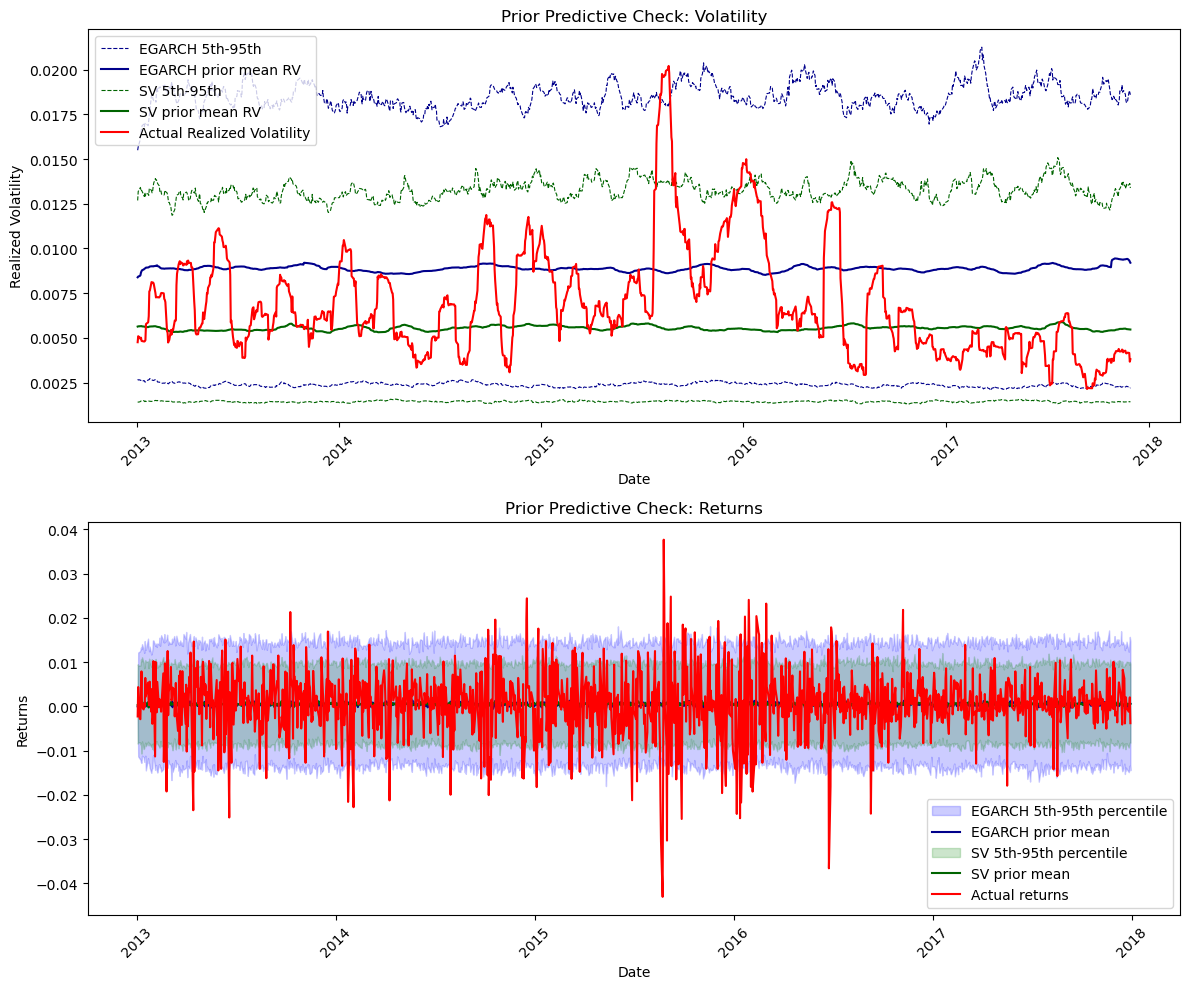

EGARCH valid paths: 991/1000 (99%)
SV valid paths:     929/1000 (93%)


In [206]:
def simulate_sv(mu, phi, sigma_eta, mu_return, n=500):
    log_sigma2 = np.zeros(n)
    r          = np.zeros(n)
    # Stationary initialization
    log_sigma2[0] = np.random.normal(mu, sigma_eta / np.sqrt(1 - phi**2))
    r[0] = mu_return + np.exp(0.5*log_sigma2[0])*np.random.normal(0,1)
    
    for t in range(1, n):
        log_sigma2[t] = mu + phi*(log_sigma2[t-1] - mu) + \
                        np.random.normal(0, sigma_eta)
        r[t] = mu_return + np.exp(0.5*log_sigma2[t]) * np.random.normal(0, 1)
    
    return r, np.sqrt(np.exp(log_sigma2))

# Prior predictive
np.random.seed(42)
n_paths = 1000
valid_paths_sv = 0
n       = len(prior_returns_1d)
vol_sv    = []
rt_sv      = []

for _ in range(n_paths):
    # Sample from priors
    mu_s        = np.random.normal(mu_kf, 1)
    phi_s       = np.random.beta(7, 1)
    sigma_eta_s = np.abs(np.random.normal(0, 0.5)) # sigma_eta is in the range
    mu_return_s = np.random.normal(mu_return, 0.001)
    
    # Stationarity check
    if np.abs(phi_s) >= 1:
        continue
    
    r, sigma = simulate_sv(mu_s, phi_s, sigma_eta_s, mu_return_s, n)
    
    if np.any(np.isnan(r)) or np.any(np.isinf(r)):
        continue
    if np.any(np.isnan(sigma)) or np.any(np.isinf(sigma)):
        continue
    if np.max(np.abs(r)) > 0.5:        # max 50% daily return
        continue
    if np.max(sigma) > 0.3:            # max 30% daily vol
        continue
    if np.min(sigma) < 1e-6:           # min vol floor
        continue
    valid_paths_sv += 1
    vol_sv.append(sigma)
    rt_sv.append(r)

vol_sv_rv = sigma_to_rv_vectorized(np.array(vol_sv),h=21)

# Define RV scale prior paths
vol_egarch_rv = sigma_to_rv_vectorized(np.array(vol_egarch), h=21)
vol_sv_rv     = sigma_to_rv_vectorized(np.array(vol_sv), h=21)
prior_vol_rv_dates = prior_dates[:vol_egarch_rv.shape[1]]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Plot 1: Volatility ─────────────────────────────────────────────────
# EGARCH
lower = np.percentile(vol_egarch_rv, 5,  axis=0)
upper = np.percentile(vol_egarch_rv, 95, axis=0)
mean  = np.mean(vol_egarch_rv, axis=0)
# Option 1 — just the boundary lines, no fill
axes[0].plot(prior_vol_rv_dates, lower, 
             color="darkblue", linewidth=0.8, linestyle='--', 
             label="EGARCH 5th-95th")
axes[0].plot(prior_vol_rv_dates, upper, 
             color="darkblue", linewidth=0.8, linestyle='--')
ql_rolling
axes[0].plot(prior_vol_rv_dates, mean, color="darkblue",
             linewidth=1.5, label="EGARCH prior mean RV")

# SV
lower = np.percentile(vol_sv_rv, 5,  axis=0)
upper = np.percentile(vol_sv_rv, 95, axis=0)
mean  = np.mean(vol_sv_rv, axis=0)
axes[0].plot(prior_vol_rv_dates, lower, 
             color="darkgreen", linewidth=0.8, linestyle='--',
             label="SV 5th-95th")
axes[0].plot(prior_vol_rv_dates, upper, 
             color="darkgreen", linewidth=0.8, linestyle='--')
axes[0].plot(prior_vol_rv_dates, mean, color="darkgreen",
             linewidth=1.5, label="SV prior mean RV")

# Actual RV
axes[0].plot(prior_rv_dates, rv_prior_1d_strict, color="red",
             linewidth=1.5, label="Actual Realized Volatility")

axes[0].set_title(f"Prior Predictive Check: Volatility")
axes[0].set_ylabel("Realized Volatility")
axes[0].set_xlabel("Date")
axes[0].legend()

# ── Plot 2: Returns ────────────────────────────────────────────────────
# EGARCH
lower = np.percentile(rt_egarch, 5,  axis=0)
upper = np.percentile(rt_egarch, 95, axis=0)
mean  = np.mean(rt_egarch, axis=0)
axes[1].fill_between(prior_ret_dates, lower, upper,
                     alpha=0.2, color="blue",
                     label="EGARCH 5th-95th percentile")
axes[1].plot(prior_ret_dates, mean, color="darkblue",
             linewidth=1.5, label="EGARCH prior mean")

# SV
lower = np.percentile(rt_sv, 5,  axis=0)
upper = np.percentile(rt_sv, 95, axis=0)
mean  = np.mean(rt_sv, axis=0)
axes[1].fill_between(prior_ret_dates, lower, upper,
                     alpha=0.2, color="green",
                     label="SV 5th-95th percentile")
axes[1].plot(prior_ret_dates, mean, color="darkgreen",
             linewidth=1.5, label="SV prior mean")

# Actual returns — once only
axes[1].plot(prior_ret_dates, prior_returns_1d[:len(prior_ret_dates)],
             color="red", linewidth=1.5, label="Actual returns")

axes[1].set_title("Prior Predictive Check: Returns")
axes[1].set_ylabel("Returns")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.savefig("combined_prior_predictive.pdf", bbox_inches='tight')
plt.show()

print(f"EGARCH valid paths: {valid_paths_egarch}/{n_paths} "
      f"({valid_paths_egarch/n_paths*100:.0f}%)")
print(f"SV valid paths:     {valid_paths_sv}/{n_paths} "
      f"({valid_paths_sv/n_paths*100:.0f}%)")


In [ ]:
Particle Filter

In [82]:
import numpy as np
from scipy import stats as scipy_stats

def particle_filter_sv(returns, mu, phi, sigma_eta, mu_return, N):
    T = len(returns)
    
    # Initialize particles from stationary distribution
    init_std = sigma_eta / np.sqrt(1 - phi**2)
    particles = np.random.normal(mu, init_std, N)
    log_likelihood = 0.0
    filtered_means = []
    
    for t in range(T):
        # 1. Propagate — state equation
        particles = mu + phi*(particles - mu) + \
                    np.random.normal(0, sigma_eta, N)
        
        # 2. Reweight — observation equation
        # how likely is the return given the volatility estimate
        sigma_t  = np.sqrt(np.exp(particles))
        log_w     = scipy_stats.norm.logpdf(returns[t], loc=mu_return, scale=sigma_t)
        max_lw    = log_w.max()                          
        log_w    -= max_lw
        weights   = np.exp(log_w) # just likelihood (the previous 2 lines are only there for numerical reasons)
        weights  /= weights.sum()
        
        log_likelihood += max_lw + np.log(np.mean(np.exp(log_w)))   
        # 3. Resample — systematic resampling
        # eliminate particles with low weights, so create try and duplicate high weights and discard low weights
        # so all N particles have similar weight
        cumsum = np.cumsum(weights)
        u      = np.random.uniform(0, 1/N) + np.arange(N)/N # note the left term is a common increase to all the particles (not n distinct)
        idx    = np.searchsorted(cumsum, u) # this is the key part of the code, 
                                            # as particles with more weight cover more interval length
        particles = particles[idx]
        
        filtered_means.append(particles.mean())
    
    return np.array(filtered_means), log_likelihood, particles

### Particle Filter REgression

In [83]:
# ── Regression PMCMC ──────────────────────────────────────────────────
# MH logic with ability to increase/decrease accepts based on how close/far away model is to correct solution.
def pmcmc_regression(returns, n_mcmc=1000, N=500,
                     mu_init=mu_kf, phi_init=0.93,
                     sigma_eta_init=sigma_eta_kf,
                     mu_return_init=mu_return):
    
    theta_current = np.array([mu_init, phi_init, 
                               sigma_eta_init, mu_return_init])
    _, ll_current, _ = particle_filter_sv(returns, *theta_current, N=N)
    
    samples    = np.zeros((n_mcmc, 4))
    ll_history = np.zeros(n_mcmc)
    accepted   = 0
    
    proposal_std   = np.array([0.2, 0.02, 0.05, 0.0002])
    target_rate    = 0.20
    adapt_interval = 50
    adapt_end      = 500
    scale_factor   = 0.85
    
    def log_prior(theta):
        mu_p, phi_p, sigma_eta_p, mu_ret_p = theta
        lp  = scipy_stats.norm.logpdf(mu_p,     mu_kf,      1.0)
        lp += scipy_stats.beta.logpdf(phi_p,    7,          1)
        lp += scipy_stats.halfnorm.logpdf(sigma_eta_p, scale=0.5)
        lp += scipy_stats.norm.logpdf(mu_ret_p, mu_return,  0.001)
        return lp
    
    print("Running Regression PMCMC...")
    for i in range(n_mcmc):
        if i > 0 and i < adapt_end and i % adapt_interval == 0:
            current_rate = accepted / i
            if current_rate < target_rate:
                proposal_std *= scale_factor
            else:
                proposal_std /= scale_factor
            proposal_std = np.clip(proposal_std, 1e-4, 1.0)
            print(f"Step {i}: rate={current_rate:.2%}, "
                  f"proposal_std={proposal_std.round(4)}")
        elif i % 100 == 0:
            print(f"Step {i}/{n_mcmc}, "
                  f"acceptance rate: {accepted/(i+1) if i>0 else 0:.2%}")
        
        theta_proposed = theta_current + np.random.normal(0, proposal_std, 4)
        
        if np.abs(theta_proposed[1]) >= 1:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        if theta_proposed[2] <= 0:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        
        _, ll_proposed, _ = particle_filter_sv(returns, *theta_proposed, N=N)
        
        log_alpha = (ll_proposed + log_prior(theta_proposed)) - \
                    (ll_current  + log_prior(theta_current))
        
        if np.log(np.random.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            accepted     += 1
        
        samples[i]    = theta_current
        ll_history[i] = ll_current
    
    print(f"Final acceptance rate: {accepted/n_mcmc:.2%}")
    return samples, ll_history


  


Running Regression PMCMC...
Step 0/3000, acceptance rate: 0.00%
Step 50: rate=16.00%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 100: rate=14.00%, proposal_std=[1.445e-01 1.440e-02 3.610e-02 1.000e-04]
Step 150: rate=20.67%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 200: rate=23.50%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 250: rate=22.40%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 300: rate=20.00%, proposal_std=[0.2768 0.0277 0.0692 0.0003]
Step 350: rate=18.57%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 400: rate=19.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 450: rate=18.67%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 500/3000, acceptance rate: 19.56%
Step 600/3000, acceptance rate: 22.96%
Step 700/3000, acceptance rate: 23.97%
Step 800/3000, acceptance rate: 24.34%
Step 900/3000, acceptance rate: 25.42%
Step 1000/3000, acceptance rate: 26.27%
Step 1100/3000, acceptance rate: 26.79%
Step 1200/3000, acceptance rate:

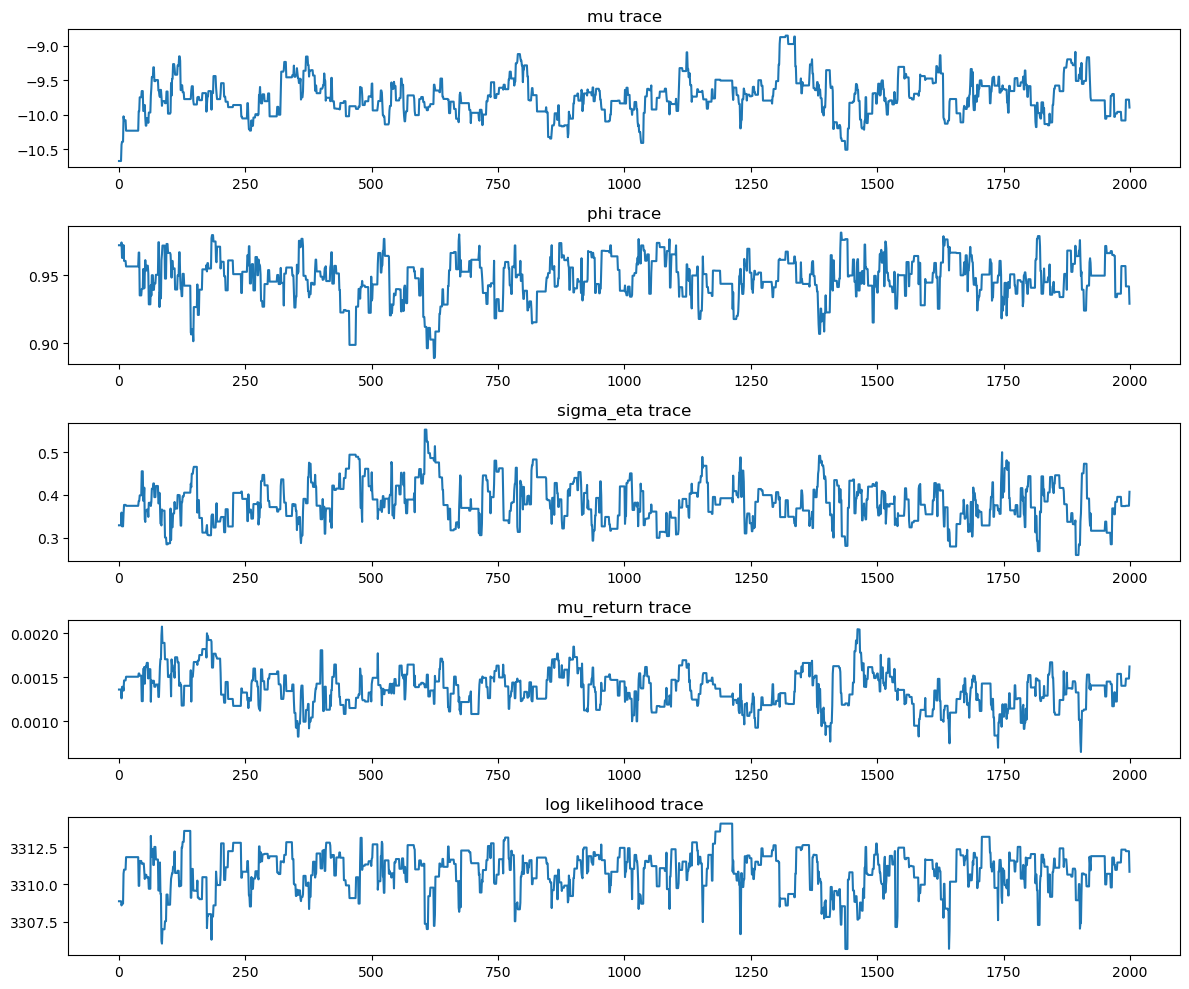

In [85]:


# Run PMCMC
samples_sv, ll_history = pmcmc_regression(
    regression_returns_1d,
    n_mcmc=3000,
    N=2000,
    mu_init=mu_kf,
    phi_init=0.875,
    sigma_eta_init=sigma_eta_kf,
    mu_return_init = mu_return
)

# Discard burn-in
burnin = 1000
samples_sv = samples_sv[burnin:]

# Results
mu_samples        = samples_sv[:, 0]
phi_samples       = samples_sv[:, 1]
sigma_eta_samples = samples_sv[:, 2]
mu_return_samples = samples_sv[:, 3]

print(f"\nPosterior means:")
print(f"mu:        {mu_samples.mean():.4f}")
print(f"phi:       {phi_samples.mean():.4f}")
print(f"sigma_eta: {sigma_eta_samples.mean():.4f}")
print(f"mu_return: {mu_return_samples.mean():.6f}")
# Plot traces
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
axes[0].plot(mu_samples);        axes[0].set_title("mu trace")
axes[1].plot(phi_samples);       axes[1].set_title("phi trace")
axes[2].plot(sigma_eta_samples); axes[2].set_title("sigma_eta trace")
axes[3].plot(mu_return_samples); axes[3].set_title("mu_return trace")
axes[4].plot(ll_history[burnin:]);  axes[4].set_title("log likelihood trace")
plt.tight_layout()
plt.show()

In [86]:
# Check log-likelihood variance
ll_after_burnin = ll_history[burnin:]
print(f"ll std: {ll_after_burnin.std():.4f}")
# Should be ~1.0 for optimal PMCMC
# If >> 1 → need more particles
# If << 1 → can reduce particles

ll std: 1.4115


In [87]:
print(f"mu mean:   {mu_samples.mean():.4f}")
print(f"mu std:    {mu_samples.std():.4f}")
print(f"mu 5-95%:  [{np.percentile(mu_samples,5):.4f}, {np.percentile(mu_samples,95):.4f}]")
print(f"mu_kf:     {mu_kf:.4f}")

mu mean:   -9.7405
mu std:    0.2720
mu 5-95%:  [-10.1599, -9.2844]
mu_kf:     -11.1010


ll std after burnin: 1.4115


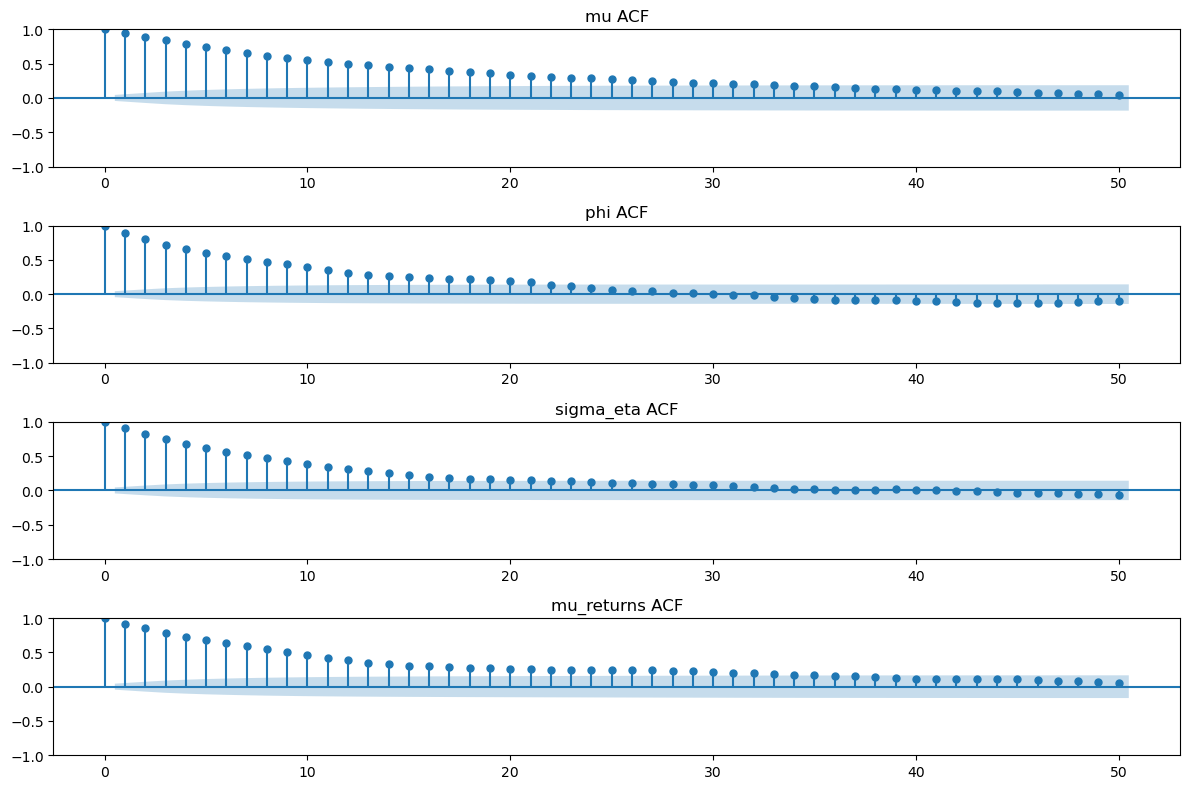

In [88]:
ll_after_burnin = ll_history[burnin:]
print(f"ll std after burnin: {ll_after_burnin.std():.4f}")

# Check ACF quickly
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
plot_acf(mu_samples, lags=50, ax=axes[0], title="mu ACF")
plot_acf(phi_samples, lags=50, ax=axes[1], title="phi ACF")
plot_acf(sigma_eta_samples, lags=50, ax=axes[2], title="sigma_eta ACF")
plot_acf(mu_return_samples, lags=50, ax=axes[3], title="mu_returns ACF")
plt.tight_layout()
plt.show()

### Plotting Realized Vol

In [91]:
# ── Step 1: Get filtered vol paths ────────────────────────────────────
thin_interval = 15
idx_thin      = np.arange(0, len(mu_samples), thin_interval)
n_thin        = len(idx_thin)

sigma_posterior_sv = np.zeros((n_thin, len(regression_returns_1d)))

for j, idx in enumerate(idx_thin):
    filtered, _, _ = particle_filter_sv(
        regression_returns_1d,
        mu=mu_samples[idx], phi=phi_samples[idx],
        sigma_eta=sigma_eta_samples[idx],
        mu_return=mu_return_samples[idx], N=1000
    )
    sigma_posterior_sv[j] = np.sqrt(np.exp(filtered))

print(f"sigma_posterior_sv shape: {sigma_posterior_sv.shape}")

# ── Step 2: Convert to RV scale ────────────────────────────────────────
sigma_posterior_rv_sv = sigma_to_rv_vectorized(sigma_posterior_sv, h=21)
print(f"sigma_posterior_rv_sv shape: {sigma_posterior_rv_sv.shape}")

# ── Step 3: Align with actual RV ───────────────────────────────────────
n_sv         = min(len(rv_regression_1d), sigma_posterior_rv_sv.shape[1])
rv_actual_sv = rv_regression_1d[:n_sv]
rv_mean_sv   = sigma_posterior_rv_sv.mean(axis=0)[:n_sv]
rv_lower_sv  = np.percentile(sigma_posterior_rv_sv, 5,  axis=0)[:n_sv]
rv_upper_sv  = np.percentile(sigma_posterior_rv_sv, 95, axis=0)[:n_sv]

sigma_posterior_sv shape: (134, 1008)
sigma_posterior_rv_sv shape: (134, 987)
Coverage (no noise):   21.07%


Measurement noise std: 0.1783
Coverage (with noise): 89.67%
COVID start: 2020-01-30 (obs 522)
COVID end:   2020-04-30 (obs 585)
Pre-COVID coverage:  89.66%
COVID coverage:      66.67%
Post-COVID coverage: 93.28%


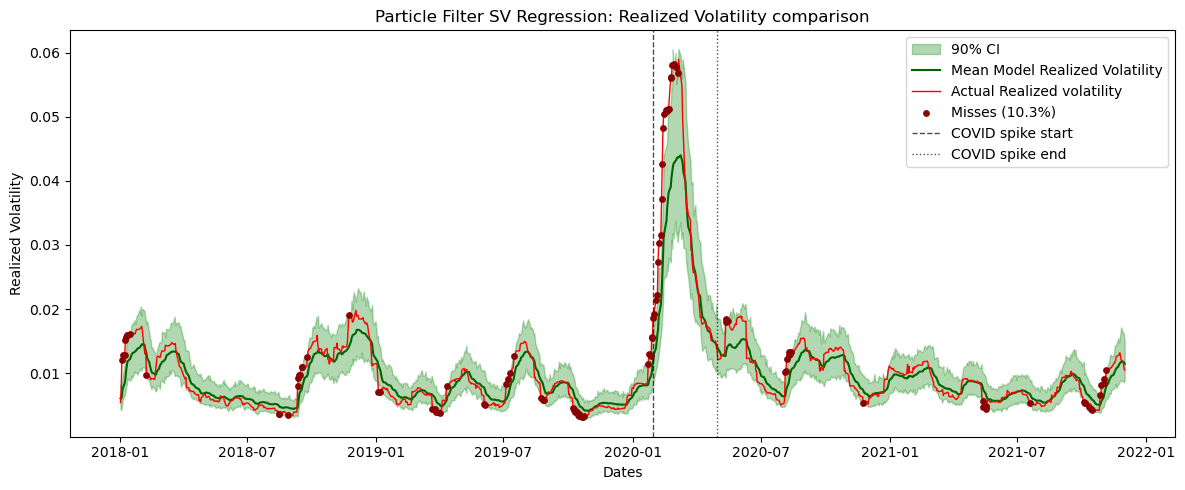

In [94]:
# Coverage with measurement noise
sigma_eta_meas_sv = np.std(np.log(rv_actual_sv) - np.log(rv_mean_sv))
print(f"Measurement noise std: {sigma_eta_meas_sv:.4f}")

noise_sv = np.random.normal(0, sigma_eta_meas_sv, 
                              size=sigma_posterior_rv_sv[:, :n_sv].shape)
sigma_posterior_rv_noisy_sv = sigma_posterior_rv_sv[:, :n_sv] * np.exp(noise_sv)

rv_lower_noisy_sv = np.percentile(sigma_posterior_rv_noisy_sv, 5,  axis=0)
rv_upper_noisy_sv = np.percentile(sigma_posterior_rv_noisy_sv, 95, axis=0)

inside_noisy_sv   = (rv_actual_sv >= rv_lower_noisy_sv) & \
                    (rv_actual_sv <= rv_upper_noisy_sv)
coverage_noisy_sv = np.mean(inside_noisy_sv)
print(f"Coverage (with noise): {coverage_noisy_sv:.2%}")

# COVID — same dates as EGARCH
print(f"COVID start: {regression_dates[covid_idx].date()} (obs {covid_idx})")
print(f"COVID end:   {regression_dates[covid_end].date()} (obs {covid_end})")

# Pre-COVID
inside_pre_sv = (rv_actual_sv[:covid_idx] >= rv_lower_noisy_sv[:covid_idx]) & \
                (rv_actual_sv[:covid_idx] <= rv_upper_noisy_sv[:covid_idx])
print(f"Pre-COVID coverage:  {np.mean(inside_pre_sv):.2%}")

# COVID period
inside_covid_sv = (rv_actual_sv[covid_idx:covid_end] >= rv_lower_noisy_sv[covid_idx:covid_end]) & \
                  (rv_actual_sv[covid_idx:covid_end] <= rv_upper_noisy_sv[covid_idx:covid_end])
print(f"COVID coverage:      {np.mean(inside_covid_sv):.2%}")

# Post-COVID
inside_post_sv = (rv_actual_sv[covid_end:n_sv] >= rv_lower_noisy_sv[covid_end:n_sv]) & \
                 (rv_actual_sv[covid_end:n_sv] <= rv_upper_noisy_sv[covid_end:n_sv])
print(f"Post-COVID coverage: {np.mean(inside_post_sv):.2%}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(regression_dates[:n_sv], rv_lower_noisy_sv, rv_upper_noisy_sv,
                alpha=0.3, color='green', label='90% CI')
ax.plot(regression_dates[:n_sv], rv_mean_sv, 
        color='darkgreen', lw=1.5, label='Mean Model Realized Volatility')
ax.plot(regression_dates[:n_sv], rv_actual_sv, 
        color='red', lw=1, label='Actual Realized volatility')

# Misses
miss_idx_sv_reg   = np.where(~inside_noisy_sv)[0]
miss_dates_sv_reg = regression_dates[miss_idx_sv_reg]
ax.scatter(miss_dates_sv_reg, rv_actual_sv[miss_idx_sv_reg],
           color='darkred', s=15, zorder=5,
           label=f'Misses ({(1-coverage_noisy_sv)*100:.1f}%)')

ax.axvline(covid_start_date, color='black', linestyle='--',
           alpha=0.7, lw=1, label='COVID spike start')
ax.axvline(covid_end_date, color='black', linestyle=':',
           alpha=0.7, lw=1, label='COVID spike end')

ax.set_title("Particle Filter SV Regression: Realized Volatility comparison")
ax.set_xlabel("Dates")
ax.set_ylabel("Realized Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("sv_regression_rv.pdf", bbox_inches='tight')
plt.show()

PIT histogram (not used since its hard to interpret)

PF SV PIT KS p-value: 0.0219
PF SV PIT coverage:   98.31%


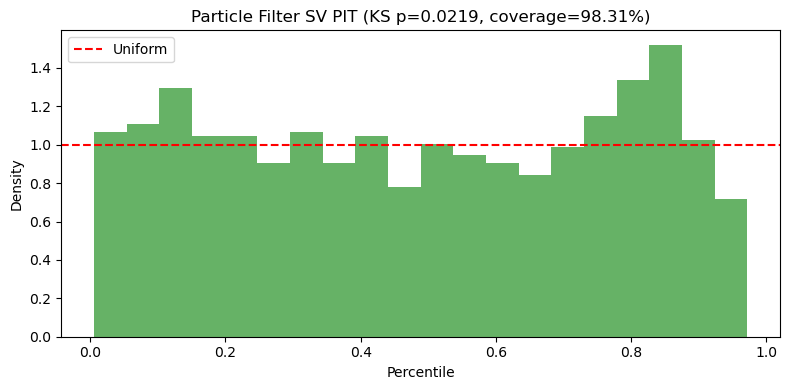

In [120]:
# ── PIT for Particle Filter SV ─────────────────────────────────────────
n_pit_sv = min(len(regression_returns_1d), sigma_posterior_sv.shape[1])

cdf_matrix_sv = scipy_stats.norm.cdf(
    regression_returns_1d[:n_pit_sv][np.newaxis, :],
    loc=mu_return_samples[idx_thin][:, np.newaxis],
    scale=sigma_posterior_sv[:, :n_pit_sv]
)
u_sv = cdf_matrix_sv.mean(axis=0)

ks_stat_sv, ks_pval_sv = scipy_stats.kstest(u_sv, 'uniform')
coverage_pit_sv = np.mean((u_sv >= 0.05) & (u_sv <= 0.95))

print(f"PF SV PIT KS p-value: {ks_pval_sv:.4f}")
print(f"PF SV PIT coverage:   {coverage_pit_sv:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(u_sv, bins=20, density=True, alpha=0.6, color='green')
ax.axhline(1, color='red', linestyle='--', label='Uniform')
ax.set_xlabel("Percentile")
ax.set_ylabel("Density")
ax.set_title(f"Particle Filter SV PIT (KS p={ks_pval_sv:.4f}, "
             f"coverage={coverage_pit_sv:.2%})")
ax.legend()
plt.tight_layout()
plt.savefig("sv_regression_pit.pdf", bbox_inches='tight')
plt.show()

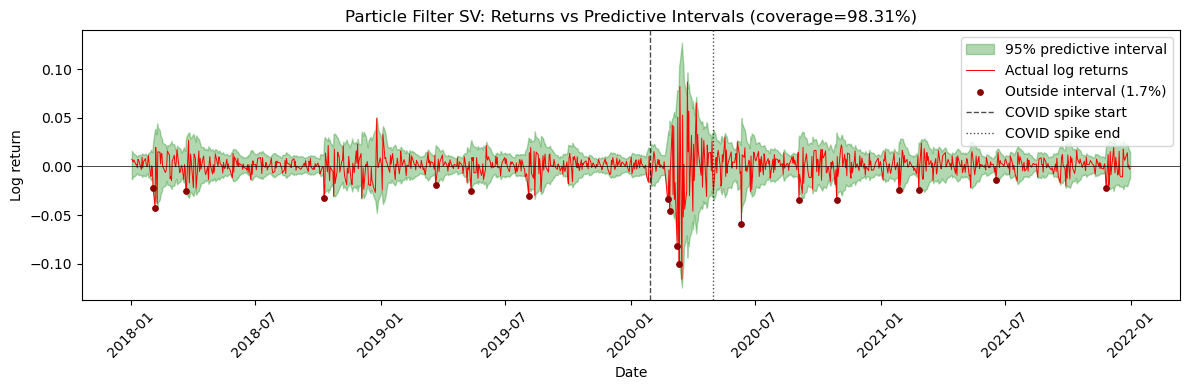

In [127]:
# ── SV Regression Returns predictive interval ──────────────────────────
mu_return_mean_sv = mu_return_samples[idx_thin].mean()
scale_mean_sv_ret = sigma_posterior_sv.mean(axis=0)

n_ret_sv = min(len(regression_returns_1d), len(scale_mean_sv_ret),
               len(regression_returns.index))

lower_ret_sv = scipy_stats.norm.ppf(0.05, loc=mu_return_mean_sv,
                                     scale=scale_mean_sv_ret)
upper_ret_sv = scipy_stats.norm.ppf(0.95, loc=mu_return_mean_sv,
                                     scale=scale_mean_sv_ret)

inside_ret_sv   = (regression_returns_1d[:n_ret_sv] >= lower_ret_sv[:n_ret_sv]) & \
                  (regression_returns_1d[:n_ret_sv] <= upper_ret_sv[:n_ret_sv])
miss_idx_ret_sv = np.where(~inside_ret_sv)[0]

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(regression_returns.index[:n_ret_sv],
                lower_ret_sv[:n_ret_sv], upper_ret_sv[:n_ret_sv],
                alpha=0.3, color='green', label='90% predictive interval')
ax.plot(regression_returns.index[:n_ret_sv],
        regression_returns_1d[:n_ret_sv], 
        color='red', lw=0.7, label='Actual log returns')
ax.scatter(regression_dates[miss_idx_ret_sv],
           regression_returns_1d[miss_idx_ret_sv],
           color='darkred', s=15, zorder=5,
           label=f'Outside interval ({(1-coverage_pit_sv)*100:.1f}%)')
ax.axhline(0, color='black', lw=0.5)

# COVID lines — already defined
ax.axvline(covid_start_date, color='black', linestyle='--',
           alpha=0.7, lw=1, label='COVID spike start')
ax.axvline(covid_end_date, color='black', linestyle=':',
           alpha=0.7, lw=1, label='COVID spike end')

ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.set_title(f"Particle Filter SV: Returns vs Predictive Intervals "
             f"(coverage={coverage_pit_sv:.2%})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sv_regression_returns_interval.pdf", bbox_inches='tight')
plt.show()

In [119]:
print("Coverage at different CI levels (SV Regression):")
print("-" * 40)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower = np.percentile(sigma_posterior_rv_noisy_sv, (100-level)/2, axis=0)
    upper = np.percentile(sigma_posterior_rv_noisy_sv, 100-(100-level)/2, axis=0)
    inside = (rv_actual_sv >= lower) & (rv_actual_sv <= upper)
    print(f"{level}% CI coverage: {np.mean(inside):.2%}")

Coverage at different CI levels (SV Regression):
----------------------------------------
50% CI coverage: 49.44%
60% CI coverage: 60.99%
70% CI coverage: 72.24%
80% CI coverage: 82.47%
85% CI coverage: 86.63%
90% CI coverage: 89.67%
95% CI coverage: 93.92%
99% CI coverage: 98.28%


In [ ]:
Key emprical CDF graph

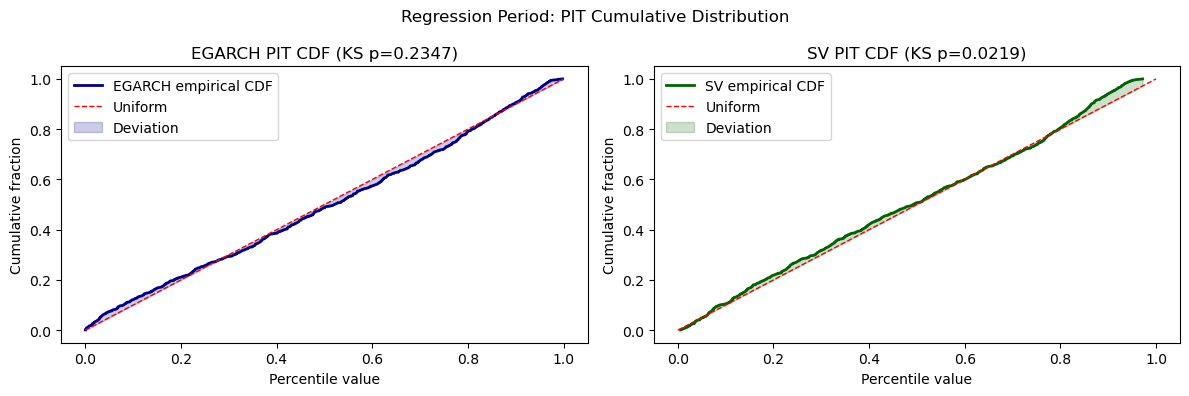

In [272]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sort u values
u_egarch_sorted = np.sort(u_egarch)
u_sv_sorted     = np.sort(u_sv)
n_e = len(u_egarch_sorted)
n_s = len(u_sv_sorted)

# Empirical CDF
ecdf_egarch = np.arange(1, n_e+1) / n_e
ecdf_sv     = np.arange(1, n_s+1) / n_s

# Uniform reference line
x_uniform = np.linspace(0, 1, 100)

# EGARCH
axes[0].plot(u_egarch_sorted, ecdf_egarch, 
             color='darkblue', lw=2, label='EGARCH empirical CDF')
axes[0].plot(x_uniform, x_uniform, 
             color='red', linestyle='--', lw=1, label='Uniform')
axes[0].fill_between(u_egarch_sorted, ecdf_egarch, u_egarch_sorted,
                     alpha=0.2, color='darkblue', label='Deviation')
axes[0].set_xlabel("Percentile value")
axes[0].set_ylabel("Cumulative fraction")
axes[0].set_title(f"EGARCH PIT CDF (KS p={ks_pval_egarch:.4f})")
axes[0].legend()

# SV
axes[1].plot(u_sv_sorted, ecdf_sv,
             color='darkgreen', lw=2, label='SV empirical CDF')
axes[1].plot(x_uniform, x_uniform,
             color='red', linestyle='--', lw=1, label='Uniform')
axes[1].fill_between(u_sv_sorted, ecdf_sv, u_sv_sorted,
                     alpha=0.2, color='darkgreen', label='Deviation')
axes[1].set_xlabel("Percentile value")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title(f"SV PIT CDF (KS p={ks_pval_sv:.4f})")
axes[1].legend()

plt.suptitle("Regression Period: PIT Cumulative Distribution")
plt.tight_layout()
plt.savefig("regression_pit_cdf.pdf", bbox_inches='tight')
plt.show()

In [115]:
sigma_mean_egarch = sigma_posterior_rv_egarch.mean(axis=0)  # RV scale
sigma_mean_sv     = sigma_posterior_rv_sv.mean(axis=0)

In [131]:
print("Return coverage at different CI levels (SV Regression):")
print("-" * 40)

for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower_u = (100 - level) / 200
    upper_u = 1 - (100 - level) / 200
    coverage_l = np.mean((u_sv >= lower_u) & (u_sv <= upper_u))
    print(f"{level}% CI coverage: {coverage_l:.2%}")

Return coverage at different CI levels (SV Regression):
----------------------------------------
50% CI coverage: 46.43%
60% CI coverage: 58.53%
70% CI coverage: 70.44%
80% CI coverage: 83.63%
85% CI coverage: 88.19%
90% CI coverage: 94.35%
95% CI coverage: 98.31%
99% CI coverage: 100.00%


### QLIKE Values

In [116]:
from scipy import stats

def qlike(sigma, rv):
    ratio = rv**2 / sigma**2
    return ratio - np.log(ratio) - 1

# ── Rolling vol forecast — RV shifted back 21 days ─────────────────────
rolling_vol_reg = full_rv.shift(21)["2018-01-01":"2021-12-31"].dropna().values.flatten()

# ── Align all lengths ──────────────────────────────────────────────────
n_dm = min(len(rv_regression_1d),
           len(rolling_vol_reg),
           len(sigma_mean_egarch),
           len(sigma_mean_sv))

rv_dm = rv_regression_1d[:n_dm]

# ── QLIKE losses ───────────────────────────────────────────────────────
ql_rolling = qlike(rolling_vol_reg[:n_dm], rv_dm)
ql_egarch  = qlike(sigma_mean_egarch[:n_dm], rv_dm)
ql_sv      = qlike(sigma_mean_sv[:n_dm], rv_dm)

# ── Results ────────────────────────────────────────────────────────────
print("Mean QLIKE (lower = better):")
print(f"Rolling: {ql_rolling.mean():.6f}")
print(f"EGARCH:  {ql_egarch.mean():.6f}")
print(f"SV:      {ql_sv.mean():.6f}")


Mean QLIKE (lower = better):
Rolling: 1.291349
EGARCH:  0.107254
SV:      0.067584


In [258]:
# ── QLIKE by COVID period ──────────────────────────────────────────────
covid_idx_dm = np.searchsorted(rv_regression_dates[:n_dm], covid_start_date)
covid_end_dm = np.searchsorted(rv_regression_dates[:n_dm], covid_end_date)

print("Mean QLIKE (lower = better):")
print(f"{'':20} {'Rolling':>10} {'EGARCH':>10} {'SV':>10}")
print("-" * 55)

# Overall
print(f"{'Overall':20} {ql_rolling.mean():>10.4f} "
      f"{ql_egarch.mean():>10.4f} {ql_sv.mean():>10.4f}")

# Pre-COVID
print(f"{'Pre-COVID':20} "
      f"{ql_rolling[:covid_idx_dm].mean():>10.4f} "
      f"{ql_egarch[:covid_idx_dm].mean():>10.4f} "
      f"{ql_sv[:covid_idx_dm].mean():>10.4f}")

# COVID spike
print(f"{'COVID spike':20} "
      f"{ql_rolling[covid_idx_dm:covid_end_dm].mean():>10.4f} "
      f"{ql_egarch[covid_idx_dm:covid_end_dm].mean():>10.4f} "
      f"{ql_sv[covid_idx_dm:covid_end_dm].mean():>10.4f}")

# Post-COVID
print(f"{'Post-COVID':20} "
      f"{ql_rolling[covid_end_dm:].mean():>10.4f} "
      f"{ql_egarch[covid_end_dm:].mean():>10.4f} "
      f"{ql_sv[covid_end_dm:].mean():>10.4f}")

Mean QLIKE (lower = better):
                        Rolling     EGARCH         SV
-------------------------------------------------------
Overall                  1.2913     0.1073     0.0676
Pre-COVID                1.2380     0.1231     0.0678
COVID spike              6.3625     0.1383     0.1794
Post-COVID               0.5659     0.0819     0.0498


Suggests that fat-tailedness isn't a major issue for the model

z_pf mean:     0.0326
z_pf std:      0.9433
z_pf skew:     -0.3566
z_pf kurtosis: -0.4983

Fitted nu: 63331869759898.6641


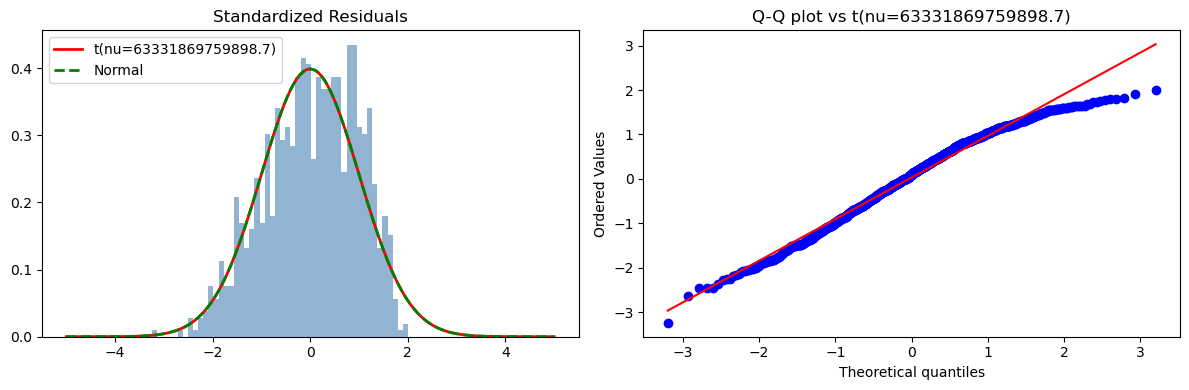

In [74]:
# Get filtered vol from posterior mean parameters
filtered_means_pf, _, _ = particle_filter_sv(
    regression_returns_1d,
    mu=mu_samples.mean(),
    phi=phi_samples.mean(),
    sigma_eta=sigma_eta_samples.mean(),
    mu_return=mu_return,
    N=1000
)
sigma_pf = np.sqrt(np.exp(filtered_means_pf))

# Standardized residuals
z_pf = (regression_returns_1d - mu_return) / sigma_pf

# Basic checks
print(f"z_pf mean:     {z_pf.mean():.4f}")   # should be ~0
print(f"z_pf std:      {z_pf.std():.4f}")    # should be ~1
print(f"z_pf skew:     {scipy_stats.skew(z_pf):.4f}")
print(f"z_pf kurtosis: {scipy_stats.kurtosis(z_pf):.4f}")  # >0 = fat tails

# Fit t-distribution
nu_pf, mu_pf_fit, scale_pf_fit = scipy_stats.t.fit(z_pf, floc=0, fscale=1)
print(f"\nFitted nu: {nu_pf:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram vs t-distribution
x = np.linspace(-5, 5, 200)
axes[0].hist(z_pf, bins=50, density=True, alpha=0.6, color='steelblue')
axes[0].plot(x, scipy_stats.t.pdf(x, df=nu_pf), 
             color='red', lw=2, label=f't(nu={nu_pf:.1f})')
axes[0].plot(x, scipy_stats.norm.pdf(x), 
             color='green', lw=2, linestyle='--', label='Normal')
axes[0].set_title("Standardized Residuals")
axes[0].legend()

# Q-Q plot
scipy_stats.probplot(z_pf, dist=scipy_stats.t(df=nu_pf), plot=axes[1])
axes[1].set_title(f"Q-Q plot vs t(nu={nu_pf:.1f})")

plt.tight_layout()
plt.show()

### Sequential Stochastic Volatility

This follows the same process as EGARCH 

In [204]:
# Extract posterior mean parameters first
mu_post_sv        = mu_samples.mean()
phi_post_sv       = phi_samples.mean()
sigma_eta_post_sv = sigma_eta_samples.mean()
mu_return_post_sv = mu_return_samples.mean()

print(f"mu_post_sv:        {mu_post_sv:.4f}")
print(f"phi_post_sv:       {phi_post_sv:.4f}")
print(f"sigma_eta_post_sv: {sigma_eta_post_sv:.4f}")
print(f"mu_return_post_sv: {mu_return_post_sv:.6f}")

# Then run particle filter
filtered_reg, _, particle_carry = particle_filter_sv(
    regression_returns_1d,
    mu=mu_post_sv,
    phi=phi_post_sv,
    sigma_eta=sigma_eta_post_sv,
    mu_return=mu_return_post_sv,
    N=2000
)

ls2_carry_sv = filtered_reg[-1]
print(f"ls2_carry_sv:   {ls2_carry_sv:.4f}")
print(f"sigma_carry_sv: {np.sqrt(np.exp(ls2_carry_sv)):.6f}")


mu_post_sv:        -9.7405
phi_post_sv:       0.9481
sigma_eta_post_sv: 0.3821
mu_return_post_sv: 0.001366
ls2_carry_sv:   -9.9810
sigma_carry_sv: 0.006802


In [205]:
# Reset before SV sequential loop
sigma_eta_noise_current = sigma_eta_meas_sv  # reset to SV regression noise
print(f"Reset sigma_eta_noise_current: {sigma_eta_noise_current:.4f}")

Reset sigma_eta_noise_current: 0.1783


In [207]:
# Window boundaries — same as EGARCH
window_boundaries = pd.date_range(start="2022-01-01",
                                   end="2026-01-01",
                                   freq="6MS")

# Verify no overlaps
for i in range(len(window_boundaries)-1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    w = full_returns[window_start:window_end]
    print(f"Window {i+1}: {w.index[0].date()} to {w.index[-1].date()}, n={len(w)}")

# Storage
all_pit_sv_seq  = []
all_vol_sv_seq  = []
all_ret_sv_seq  = []
all_window_stats_sv = []

# Initialize particle cloud from regression end state
N_seq     = 2000
particles = particle_carry.copy()

# Noise from regression
sigma_eta_noise_current = sigma_eta_meas_sv

print(f"Initial params:")
print(f"mu:        {mu_post_sv:.4f}")
print(f"phi:       {phi_post_sv:.4f}")
print(f"sigma_eta: {sigma_eta_post_sv:.4f}")
print(f"mu_return: {mu_return_post_sv:.6f}")
print(f"sigma_carry: {np.sqrt(np.exp(ls2_carry_sv)):.6f}")

Window 1: 2022-01-03 to 2022-06-30, n=124
Window 2: 2022-07-01 to 2022-12-30, n=127
Window 3: 2023-01-03 to 2023-06-30, n=124
Window 4: 2023-07-03 to 2023-12-29, n=126
Window 5: 2024-01-02 to 2024-06-28, n=124
Window 6: 2024-07-01 to 2024-12-31, n=128
Window 7: 2025-01-02 to 2025-06-30, n=122
Window 8: 2025-07-01 to 2025-12-30, n=127
Initial params:
mu:        -9.7405
phi:       0.9481
sigma_eta: 0.3821
mu_return: 0.001366
sigma_carry: 0.006802


In [208]:
def pmcmc_sequential(returns, n_mcmc=1000, N=500,
                     mu_init=None, phi_init=None,
                     sigma_eta_init=None, mu_return_init=None,
                     # Prior parameters — updated from previous posterior
                     mu_prior_mu=None, mu_prior_std=1.0,
                     phi_prior_a=7, phi_prior_b=1,
                     sigma_eta_prior_scale=0.5,
                     mu_return_prior_mu=None, mu_return_prior_std=0.001):
    
    mu_prior_mu        = mu_prior_mu or mu_init
    mu_return_prior_mu = mu_return_prior_mu or mu_return_init
    
    theta_current = np.array([mu_init, phi_init,
                               sigma_eta_init, mu_return_init])
    _, ll_current, _ = particle_filter_sv(returns, *theta_current, N=N)
    
    samples    = np.zeros((n_mcmc, 4))
    ll_history = np.zeros(n_mcmc)
    accepted   = 0
    
    proposal_std   = np.array([0.2, 0.02, 0.05, 0.0002])
    target_rate    = 0.20
    adapt_interval = 50
    adapt_end      = 500
    scale_factor   = 0.85
    
    def log_prior(theta):
        mu_p, phi_p, sigma_eta_p, mu_ret_p = theta
        lp  = scipy_stats.norm.logpdf(mu_p,     mu_prior_mu,        mu_prior_std)
        lp += scipy_stats.beta.logpdf(phi_p,    phi_prior_a,        phi_prior_b)
        lp += scipy_stats.halfnorm.logpdf(sigma_eta_p, scale=sigma_eta_prior_scale)
        lp += scipy_stats.norm.logpdf(mu_ret_p, mu_return_prior_mu, mu_return_prior_std)
        return lp
    
    print("Running Sequential PMCMC...")
    for i in range(n_mcmc):
        if i > 0 and i < adapt_end and i % adapt_interval == 0:
            current_rate = accepted / i
            if current_rate < target_rate:
                proposal_std *= scale_factor
            else:
                proposal_std /= scale_factor
            proposal_std = np.clip(proposal_std, 1e-4, 1.0)
            print(f"Step {i}: rate={current_rate:.2%}, "
                  f"proposal_std={proposal_std.round(4)}")
        elif i % 100 == 0:
            print(f"Step {i}/{n_mcmc}, "
                  f"acceptance rate: {accepted/(i+1) if i>0 else 0:.2%}")
        
        theta_proposed = theta_current + np.random.normal(0, proposal_std, 4)
        
        if np.abs(theta_proposed[1]) >= 1:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        if theta_proposed[2] <= 0:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        
        _, ll_proposed, _ = particle_filter_sv(returns, *theta_proposed, N=N)
        
        log_alpha = (ll_proposed + log_prior(theta_proposed)) - \
                    (ll_current  + log_prior(theta_current))
        
        if np.log(np.random.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            accepted     += 1
        
        samples[i]    = theta_current
        ll_history[i] = ll_current
    
    print(f"Final acceptance rate: {accepted/n_mcmc:.2%}")
    return samples, ll_history
  


In [209]:
# Initialize prior params before loop
phi_a_new, phi_b_new       = fit_beta_params(phi_samples)
sigma_eta_scale_new        = max(float(sigma_eta_samples.std()), 0.05)
mu_std_new                 = max(float(mu_samples.std()), 0.1)
mu_return_std_new          = max(float(mu_return_samples.std()), 0.0001)

for i in range(len(window_boundaries)-1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    
    window_returns = full_returns[window_start:window_end]\
                     .values.flatten().astype('float64')
    window_rv      = full_rv[window_start:window_end]\
                     .dropna().values.flatten()
    
    if len(window_returns) < 50:
        continue
    
    print(f"\nWindow {i+1}: {window_start.date()} to {window_end.date()}, "
          f"n={len(window_returns)}")
    
    # ── Step 1: Sequential evaluation BEFORE refit ────────────────────
    pit_w = []
    vol_w = []
    
    for r_t in window_returns:
        # 1. Propagate
        particles = mu_post_sv + phi_post_sv*(particles - mu_post_sv) + \
                    np.random.normal(0, sigma_eta_post_sv, N_seq)
        
        # 2. Reweight
        sigma_t = np.sqrt(np.exp(particles))
        log_w   = scipy_stats.norm.logpdf(r_t,
                                           loc=mu_return_post_sv,
                                           scale=sigma_t)
        max_lw  = log_w.max()
        log_w  -= max_lw
        weights = np.exp(log_w)
        weights /= weights.sum()
        
        # 3. PIT — before update
        u_t = np.mean(scipy_stats.norm.cdf(r_t,
                                            loc=mu_return_post_sv,
                                            scale=sigma_t))
        pit_w.append(u_t)
        vol_w.append(np.sum(weights * sigma_t))
        
        # 4. Resample
        cumsum    = np.cumsum(weights)
        u_rs      = np.random.uniform(0, 1/N_seq) + np.arange(N_seq)/N_seq
        idx_rs    = np.searchsorted(cumsum, u_rs)
        particles = particles[idx_rs]
    
    # Store
    all_pit_sv_seq.extend(pit_w)
    all_vol_sv_seq.extend(vol_w)
    all_ret_sv_seq.extend(window_returns)
    
    all_window_stats_sv.append({
        "window":          i+1,
        "start":           str(window_start.date()),
        "end":             str(window_end.date()),
        "n_obs":           len(window_returns),
        "pit_coverage":    float(np.mean((np.array(pit_w) >= 0.025) &
                                          (np.array(pit_w) <= 0.975))),
        "mu":              float(mu_post_sv),
        "phi":             float(phi_post_sv),
        "sigma_eta":       float(sigma_eta_post_sv),
        "mu_return":       float(mu_return_post_sv),
        "sigma_eta_noise": float(sigma_eta_noise_current)
    })
    print(f"Window {i+1} PIT coverage: {all_window_stats_sv[-1]['pit_coverage']:.2%}")
    
    # ── Step 2: Refit PMCMC with updated priors ───────────────────────
    samples_w_sv, _ = pmcmc_sequential(
        window_returns,
        n_mcmc=1500, N=2000,
        mu_init=mu_post_sv,
        phi_init=phi_post_sv,
        sigma_eta_init=sigma_eta_post_sv,
        mu_return_init=mu_return_post_sv,
        mu_prior_mu=mu_post_sv,
        mu_prior_std=mu_std_new,
        phi_prior_a=phi_a_new,
        phi_prior_b=phi_b_new,
        sigma_eta_prior_scale=sigma_eta_scale_new,
        mu_return_prior_mu=mu_return_post_sv,
        mu_return_prior_std=mu_return_std_new
    )
    burnin_w     = 500
    samples_w_sv = samples_w_sv[burnin_w:]
    
    print(f"Window {i+1} acceptance rate: "
          f"{samples_w_sv.shape[0]/(1500-500):.2%}")
    
    # ── Step 3: Update parameters ─────────────────────────────────────
    mu_post_sv        = samples_w_sv[:, 0].mean()
    phi_post_sv       = samples_w_sv[:, 1].mean()
    sigma_eta_post_sv = samples_w_sv[:, 2].mean()
    mu_return_post_sv = samples_w_sv[:, 3].mean()
    
    print(f"Updated params: mu={mu_post_sv:.4f}, phi={phi_post_sv:.4f}, "
          f"sigma_eta={sigma_eta_post_sv:.4f}, mu_return={mu_return_post_sv:.6f}")
    
    # ── Step 4: Update prior params for next window ───────────────────
    phi_a_new, phi_b_new    = fit_beta_params(samples_w_sv[:, 1])
    sigma_eta_scale_new     = max(float(samples_w_sv[:, 2].std()), 0.05)
    mu_std_new              = max(float(samples_w_sv[:, 0].std()), 0.1)
    mu_return_std_new       = max(float(samples_w_sv[:, 3].std()), 0.0001)
    
    # ── Step 5: Update noise estimate ────────────────────────────────
    filtered_w, _, particles = particle_filter_sv(
        window_returns,
        mu=mu_post_sv, phi=phi_post_sv,
        sigma_eta=sigma_eta_post_sv,
        mu_return=mu_return_post_sv,
        N=N_seq
    )
    sigma_w  = np.sqrt(np.exp(filtered_w))
    vol_rv_w = sigma_to_rv_vectorized(sigma_w.reshape(1,-1), h=21).flatten()
    
    window_rv_strict = window_rv[:-21] if len(window_rv) > 21 else window_rv
    n_noise = min(len(window_rv_strict), len(vol_rv_w))
    
    if n_noise > 21:
        sigma_eta_noise_current = np.std(
            np.log(window_rv_strict[:n_noise]) - np.log(vol_rv_w[:n_noise]))
        print(f"Updated noise std: {sigma_eta_noise_current:.4f}")
    
    print(f"Carry forward sigma: {np.sqrt(np.exp(filtered_w[-1])):.6f}")

# ── Final evaluation ───────────────────────────────────────────────────
all_pit_sv_seq = np.array(all_pit_sv_seq)
all_vol_sv_seq = np.array(all_vol_sv_seq)
all_ret_sv_seq = np.array(all_ret_sv_seq)

ks_stat_sv_seq, ks_pval_sv_seq = scipy_stats.kstest(all_pit_sv_seq, 'uniform')
coverage_pit_sv_seq = np.mean((all_pit_sv_seq >= 0.025) &
                               (all_pit_sv_seq <= 0.975))
print(f"\nFinal Sequential Results:")
print(f"PIT KS p-value: {ks_pval_sv_seq:.4f}")
print(f"PIT coverage:   {coverage_pit_sv_seq:.2%}")
print(f"Total obs:      {len(all_pit_sv_seq)}")


Window 1: 2022-01-01 to 2022-06-30, n=124
Window 1 PIT coverage: 95.16%
Running Sequential PMCMC...
Step 0/1500, acceptance rate: 0.00%
Step 50: rate=28.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 100: rate=22.00%, proposal_std=[0.2768 0.0277 0.0692 0.0003]
Step 150: rate=16.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 200: rate=18.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 250: rate=19.60%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 300: rate=20.33%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 350: rate=20.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 400: rate=19.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 450: rate=20.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 500/1500, acceptance rate: 20.16%
Step 600/1500, acceptance rate: 19.80%
Step 700/1500, acceptance rate: 20.11%
Step 800/1500, acceptance rate: 19.98%
Step 900/1500, acceptance rate: 19.42%
Step 1000/1500, acceptance 

In order to determine the noise

In [244]:
# ── Initialize with regression residuals ───────────────────────────────
all_log_resid_sv = list(
    np.log(rv_actual_sv) - np.log(rv_mean_sv))

print(f"Regression noise: {np.std(all_log_resid_sv):.4f}")

# ── Accumulate window residuals ────────────────────────────────────────
noise_running_sv = [np.std(all_log_resid_sv)]  # window 0 = regression

seq_vol_rv_sv_seq = sigma_to_rv_vectorized(
    np.array(all_vol_sv_seq).reshape(1,-1), h=21).flatten()

cumulative = 0
for j, stat in enumerate(all_window_stats_sv):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, len(seq_vol_rv_sv_seq))
    n_valid = min(end_idx - cumulative,
                  len(rv_sequential_1d) - cumulative)

    if n_valid > 21:
        rv_w  = rv_sequential_1d[cumulative:cumulative+n_valid]
        vol_w = seq_vol_rv_sv_seq[cumulative:cumulative+n_valid]
        log_resid_w = np.log(rv_w) - np.log(vol_w)
        all_log_resid_sv.extend(log_resid_w)

    noise_running_sv.append(np.std(all_log_resid_sv))
    print(f"Window {j+1}: n_total={len(all_log_resid_sv)}, "
          f"noise={noise_running_sv[-1]:.4f}")
    cumulative += n_w

# ── Build noisy vol per window ─────────────────────────────────────────
vol_noisy_combined_sv = np.zeros((200, len(seq_vol_rv_sv_seq)))

cumulative = 0
for j, stat in enumerate(all_window_stats_sv):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, len(seq_vol_rv_sv_seq))
    if cumulative >= len(seq_vol_rv_sv_seq):
        break
    n_valid = end_idx - cumulative
    noise_w = np.random.normal(0, noise_running_sv[j],
                                size=(200, n_valid))
    vol_noisy_combined_sv[:, cumulative:end_idx] = \
        seq_vol_rv_sv_seq[cumulative:end_idx].reshape(1,-1) * np.exp(noise_w)
    cumulative += n_w

# ── CI bands ───────────────────────────────────────────────────────────
rv_lower_seq_sv = np.percentile(vol_noisy_combined_sv, 5,  axis=0)
rv_upper_seq_sv = np.percentile(vol_noisy_combined_sv, 95, axis=0)

n_rv_seq_sv = min(len(rv_sequential_1d), len(seq_vol_rv_sv_seq))

# ── RV Coverage at different levels ───────────────────────────────────
print("\nSV Sequential RV Coverage at different CI levels:")
print("-" * 40)
for level in [80, 85, 90, 95, 99]:
    lower_l = np.percentile(vol_noisy_combined_sv, (100-level)/2, axis=0)
    upper_l = np.percentile(vol_noisy_combined_sv, 100-(100-level)/2, axis=0)
    inside_l = (rv_sequential_1d[:n_rv_seq_sv] >= lower_l[:n_rv_seq_sv]) & \
               (rv_sequential_1d[:n_rv_seq_sv] <= upper_l[:n_rv_seq_sv])
    print(f"{level}% CI coverage: {np.mean(inside_l):.2%}")

# Main 90% coverage
inside_rv_seq_sv   = (rv_sequential_1d[:n_rv_seq_sv] >=
                      rv_lower_seq_sv[:n_rv_seq_sv]) & \
                     (rv_sequential_1d[:n_rv_seq_sv] <=
                      rv_upper_seq_sv[:n_rv_seq_sv])
coverage_rv_seq_sv = np.mean(inside_rv_seq_sv)
print(f"\nMain 90% CI coverage: {coverage_rv_seq_sv:.2%}")

# ── Per window RV breakdown ────────────────────────────────────────────
print("\nPer window RV breakdown:")
cumulative = 0
for j, stat in enumerate(all_window_stats_sv):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, n_rv_seq_sv)
    if cumulative >= n_rv_seq_sv:
        print(f"Window {stat['window']}: no RV data")
        cumulative += n_w
        continue
    rv_w    = rv_sequential_1d[cumulative:end_idx]
    lower_w = rv_lower_seq_sv[cumulative:end_idx]
    upper_w = rv_upper_seq_sv[cumulative:end_idx]
    n_valid = min(len(rv_w), len(lower_w))
    if n_valid == 0:
        cumulative += n_w
        continue
    inside_w = (rv_w[:n_valid] >= lower_w[:n_valid]) & \
               (rv_w[:n_valid] <= upper_w[:n_valid])
    print(f"Window {stat['window']} ({stat['start']} to {stat['end']}): "
          f"RV={np.mean(inside_w):.2%}, "
          f"noise={noise_running_sv[j]:.4f}, "       # ← updated
          f"ratio={rv_w.mean()/seq_vol_rv_sv_seq[cumulative:end_idx].mean():.3f}")
    cumulative += n_w

# ── Return coverage from PIT ───────────────────────────────────────────
print("\nSV Sequential Return Coverage at different CI levels:")
print("-" * 40)
all_pit_sv_arr = np.array(all_pit_sv_seq)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower_u    = (100 - level) / 200
    upper_u    = 1 - (100 - level) / 200
    coverage_l = np.mean((all_pit_sv_arr >= lower_u) &
                          (all_pit_sv_arr <= upper_u))
    print(f"{level}% CI coverage: {coverage_l:.2%}")

# ── Per window return coverage ─────────────────────────────────────────
print("\nPer window return (PIT) coverage:")
cumulative = 0
for stat in all_window_stats_sv:
    n_w   = stat['n_obs']
    pit_w = all_pit_sv_arr[cumulative:cumulative+n_w]
    cov_w = np.mean((pit_w >= 0.025) & (pit_w <= 0.975))
    print(f"Window {stat['window']} ({stat['start']} to {stat['end']}): "
          f"{cov_w:.2%}")
    cumulative += n_w

Regression noise: 0.1783
Window 1: n_total=1111, noise=0.1709
Window 2: n_total=1238, noise=0.1684
Window 3: n_total=1362, noise=0.1979
Window 4: n_total=1488, noise=0.2076
Window 5: n_total=1612, noise=0.2106
Window 6: n_total=1740, noise=0.2150
Window 7: n_total=1862, noise=0.2339
Window 8: n_total=1968, noise=0.2319

SV Sequential RV Coverage at different CI levels:
----------------------------------------
80% CI coverage: 64.12%
85% CI coverage: 68.60%
90% CI coverage: 74.11%
95% CI coverage: 80.63%
99% CI coverage: 88.58%

Main 90% CI coverage: 74.11%

Per window RV breakdown:
Window 1 (2022-01-01 to 2022-06-30): RV=100.00%, noise=0.1783, ratio=1.013
Window 2 (2022-07-01 to 2022-12-31): RV=97.64%, noise=0.1709, ratio=1.044
Window 3 (2023-01-01 to 2023-06-30): RV=37.10%, noise=0.1684, ratio=0.711
Window 4 (2023-07-01 to 2023-12-31): RV=58.73%, noise=0.1979, ratio=0.761
Window 5 (2024-01-01 to 2024-06-30): RV=73.39%, noise=0.2076, ratio=0.838
Window 6 (2024-07-01 to 2024-12-31): RV=

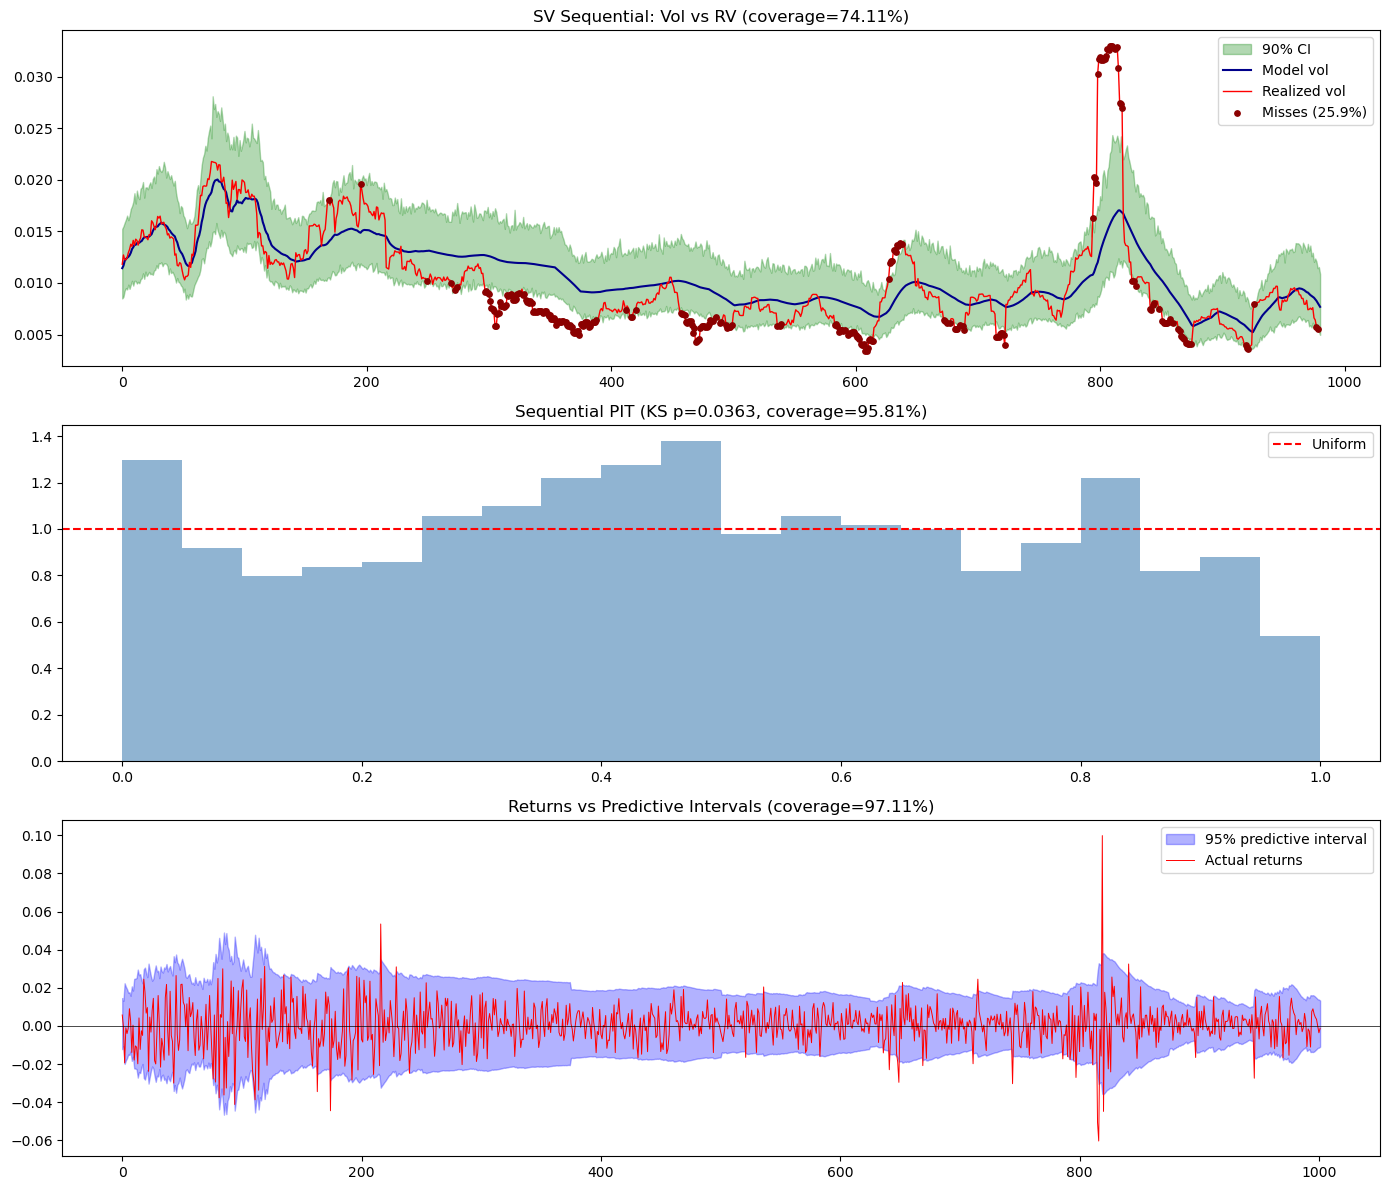

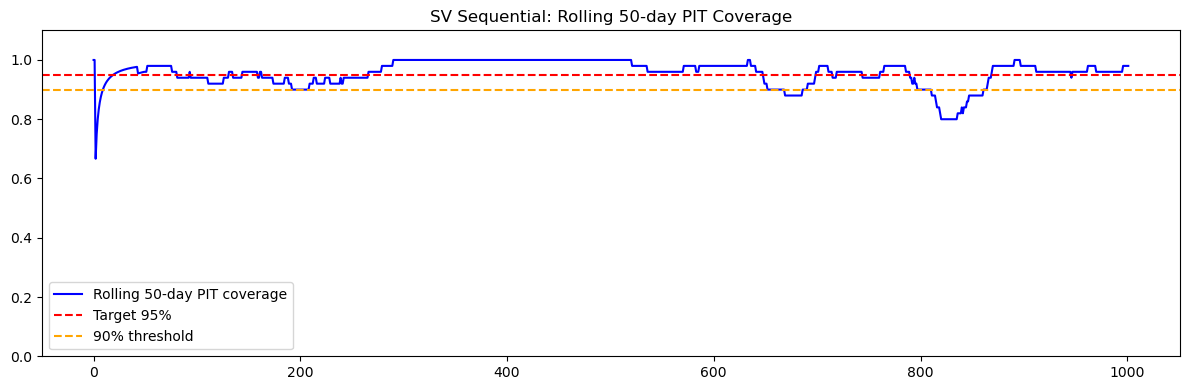

In [245]:

# ── Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. RV plot with misses
miss_idx_sv = np.where(~inside_rv_seq_sv[:n_rv_sv])[0]
axes[0].fill_between(range(n_rv_sv), 
                     rv_lower_seq_sv[:n_rv_sv], rv_upper_seq_sv[:n_rv_sv],
                     alpha=0.3, color='green', label='90% CI')
axes[0].plot(seq_vol_rv_sv[:n_rv_sv], color='darkblue', 
             lw=1.5, label='Model vol')
axes[0].plot(rv_sequential_1d[:n_rv_sv], color='red', 
             lw=1, label='Realized vol')
axes[0].scatter(miss_idx_sv, rv_sequential_1d[miss_idx_sv],
                color='darkred', s=15, zorder=5,
                label=f'Misses ({(1-coverage_rv_seq_sv)*100:.1f}%)')
axes[0].set_title(f"SV Sequential: Vol vs RV (coverage={coverage_rv_seq_sv:.2%})")
axes[0].legend()

# 2. PIT histogram
axes[1].hist(all_pit_sv_seq, bins=20, density=True, 
             alpha=0.6, color='steelblue')
axes[1].axhline(1, color='red', linestyle='--', label='Uniform')
axes[1].set_title(f"Sequential PIT (KS p={ks_pval_sv_seq:.4f}, "
                  f"coverage={coverage_pit_sv_seq:.2%})")
axes[1].legend()

# 3. Returns plot
lower_ret_sv = scipy_stats.norm.ppf(0.025, loc=mu_return_post_sv,
                                     scale=all_vol_sv_seq)
upper_ret_sv = scipy_stats.norm.ppf(0.975, loc=mu_return_post_sv,
                                     scale=all_vol_sv_seq)
inside_ret_sv = (all_ret_sv_seq >= lower_ret_sv) & \
                (all_ret_sv_seq <= upper_ret_sv)

axes[2].fill_between(range(len(all_ret_sv_seq)), 
                     lower_ret_sv, upper_ret_sv,
                     alpha=0.3, color='blue', label='95% predictive interval')
axes[2].plot(all_ret_sv_seq, color='red', lw=0.7, label='Actual returns')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_title(f"Returns vs Predictive Intervals "
                  f"(coverage={np.mean(inside_ret_sv):.2%})")
axes[2].legend()

plt.tight_layout()
plt.savefig("sv_sequential.pdf", bbox_inches='tight')
plt.show()

# ── Rolling coverage ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
rolling_pit_sv = pd.Series(
    ((all_pit_sv_seq >= 0.025) & (all_pit_sv_seq <= 0.975)).astype(float)
).rolling(50, min_periods=1).mean()

ax.plot(rolling_pit_sv, color='blue', lw=1.5, label='Rolling 50-day PIT coverage')
ax.axhline(0.95, color='red', linestyle='--', label='Target 95%')
ax.axhline(0.90, color='orange', linestyle='--', label='90% threshold')
ax.set_ylim(0, 1.1)
ax.set_title("SV Sequential: Rolling 50-day PIT Coverage")
ax.legend()
plt.tight_layout()
plt.savefig("sv_sequential_rolling.pdf", bbox_inches='tight')
plt.show()

In [ ]:
Raw values for monthly breakdown given below. Not particulary interpretable.

In [213]:
# Within-window monthly breakdown
print("Monthly breakdown within windows:")
cumulative = 0
for stat in all_window_stats_egarch:
    window_start = pd.Timestamp(stat['start'])
    window_end   = pd.Timestamp(stat['end'])
    
    # Get monthly boundaries within window
    monthly = pd.date_range(start=window_start, end=window_end, freq='MS')
    
    print(f"\nWindow {stat['window']} ({stat['start']} to {stat['end']}):")
    
    month_start_idx = cumulative
    for m in range(len(monthly)-1):
        m_start = monthly[m]
        m_end   = monthly[m+1] - pd.Timedelta(days=1)
        
        # Get returns in this month
        m_returns = full_returns[m_start:m_end]
        n_m       = len(m_returns)
        end_idx   = month_start_idx + n_m
        
        # PIT coverage for this month
        pit_m = np.array(all_pit_values_egarch)[month_start_idx:end_idx]
        cov_m = np.mean((pit_m >= 0.025) & (pit_m <= 0.975))
        
        # RV coverage for this month
        if month_start_idx < n_rv_seq_egarch:
            rv_m      = rv_sequential_1d[month_start_idx:
                                          min(end_idx, n_rv_seq_egarch)]
            lower_m   = rv_lower_seq_egarch[month_start_idx:
                                             min(end_idx, n_rv_seq_egarch)]
            upper_m   = rv_upper_seq_egarch[month_start_idx:
                                             min(end_idx, n_rv_seq_egarch)]
            inside_m  = (rv_m >= lower_m) & (rv_m <= upper_m)
            rv_cov_m  = np.mean(inside_m)
        else:
            rv_cov_m = float('nan')
        
        print(f"  Month {m+1} ({m_start.strftime('%Y-%m')}): "
              f"PIT={cov_m:.2%}, RV={rv_cov_m:.2%}, n={n_m}")
        
        month_start_idx += n_m
    
    cumulative += stat['n_obs']

Monthly breakdown within windows:

Window 1 (2022-01-01 to 2022-06-30):
  Month 1 (2022-01): PIT=95.00%, RV=100.00%, n=20
  Month 2 (2022-02): PIT=94.74%, RV=100.00%, n=19
  Month 3 (2022-03): PIT=95.65%, RV=100.00%, n=23
  Month 4 (2022-04): PIT=90.00%, RV=100.00%, n=20
  Month 5 (2022-05): PIT=90.48%, RV=100.00%, n=21

Window 2 (2022-07-01 to 2022-12-31):
  Month 1 (2022-07): PIT=100.00%, RV=100.00%, n=20
  Month 2 (2022-08): PIT=91.30%, RV=86.96%, n=23
  Month 3 (2022-09): PIT=95.24%, RV=90.48%, n=21
  Month 4 (2022-10): PIT=100.00%, RV=100.00%, n=21
  Month 5 (2022-11): PIT=85.71%, RV=95.24%, n=21

Window 3 (2023-01-01 to 2023-06-30):
  Month 1 (2023-01): PIT=100.00%, RV=85.00%, n=20
  Month 2 (2023-02): PIT=100.00%, RV=0.00%, n=19
  Month 3 (2023-03): PIT=100.00%, RV=17.39%, n=23
  Month 4 (2023-04): PIT=94.74%, RV=31.58%, n=19
  Month 5 (2023-05): PIT=100.00%, RV=0.00%, n=22

Window 4 (2023-07-01 to 2023-12-31):
  Month 1 (2023-07): PIT=100.00%, RV=10.00%, n=20
  Month 2 (2023-08

In [216]:
# Within-window monthly breakdown — SV
print("SV Monthly breakdown within windows:")
cumulative = 0
for stat in all_window_stats_sv:
    window_start = pd.Timestamp(stat['start'])
    window_end   = pd.Timestamp(stat['end'])
    
    # Get monthly boundaries within window
    monthly = pd.date_range(start=window_start, end=window_end, freq='MS')
    
    print(f"\nWindow {stat['window']} ({stat['start']} to {stat['end']}):")
    
    month_start_idx = cumulative
    for m in range(len(monthly)-1):
        m_start = monthly[m]
        m_end   = monthly[m+1] - pd.Timedelta(days=1)
        
        # Get returns in this month
        m_returns = full_returns[m_start:m_end]
        n_m       = len(m_returns)
        end_idx   = month_start_idx + n_m
        
        # PIT coverage for this month
        pit_m = np.array(all_pit_sv_seq)[month_start_idx:end_idx]
        cov_m = np.mean((pit_m >= 0.025) & (pit_m <= 0.975))
        
        # RV coverage for this month
        if month_start_idx < n_rv_seq_sv:
            rv_m     = rv_sequential_1d[month_start_idx:
                                         min(end_idx, n_rv_seq_sv)]
            lower_m  = rv_lower_seq_sv[month_start_idx:
                                        min(end_idx, n_rv_seq_sv)]
            upper_m  = rv_upper_seq_sv[month_start_idx:
                                        min(end_idx, n_rv_seq_sv)]
            inside_m = (rv_m >= lower_m) & (rv_m <= upper_m)
            rv_cov_m = np.mean(inside_m) if len(inside_m) > 0 else float('nan')
        else:
            rv_cov_m = float('nan')
        
        print(f"  Month {m+1} ({m_start.strftime('%Y-%m')}): "
              f"PIT={cov_m:.2%}, RV={rv_cov_m:.2%}, n={n_m}")
        
        month_start_idx += n_m
    
    cumulative += stat['n_obs']

SV Monthly breakdown within windows:

Window 1 (2022-01-01 to 2022-06-30):
  Month 1 (2022-01): PIT=95.00%, RV=100.00%, n=20
  Month 2 (2022-02): PIT=100.00%, RV=100.00%, n=19
  Month 3 (2022-03): PIT=95.65%, RV=100.00%, n=23
  Month 4 (2022-04): PIT=90.00%, RV=100.00%, n=20
  Month 5 (2022-05): PIT=95.24%, RV=100.00%, n=21

Window 2 (2022-07-01 to 2022-12-31):
  Month 1 (2022-07): PIT=95.00%, RV=100.00%, n=20
  Month 2 (2022-08): PIT=91.30%, RV=100.00%, n=23
  Month 3 (2022-09): PIT=95.24%, RV=100.00%, n=21
  Month 4 (2022-10): PIT=90.48%, RV=100.00%, n=21
  Month 5 (2022-11): PIT=90.48%, RV=100.00%, n=21

Window 3 (2023-01-01 to 2023-06-30):
  Month 1 (2023-01): PIT=100.00%, RV=90.00%, n=20
  Month 2 (2023-02): PIT=100.00%, RV=100.00%, n=19
  Month 3 (2023-03): PIT=100.00%, RV=30.43%, n=23
  Month 4 (2023-04): PIT=100.00%, RV=21.05%, n=19
  Month 5 (2023-05): PIT=100.00%, RV=0.00%, n=22

Window 4 (2023-07-01 to 2023-12-31):
  Month 1 (2023-07): PIT=100.00%, RV=20.00%, n=20
  Month 2 

In [174]:
log_resid_reg_egarch = np.log(rv_actual_egarch) - np.log(rv_mean_egarch)

print(f"EGARCH residuals — mean: {log_resid_reg_egarch.mean():.4f}, "
      f"std: {log_resid_reg_egarch.std():.4f}")

# SV
log_resid_reg_sv = np.log(rv_actual_sv) - np.log(rv_mean_sv)

print(f"SV residuals — mean: {log_resid_reg_sv.mean():.4f}, "
      f"std: {log_resid_reg_sv.std():.4f}")

EGARCH residuals — mean: -0.1428, std: 0.2052
SV residuals — mean: -0.0098, std: 0.1783


In [177]:
all_pit_egarch_arr = np.array(all_pit_values_egarch)
all_pit_sv_arr     = np.array(all_pit_sv_seq)

# Verify lengths match
print(f"EGARCH PIT length: {len(all_pit_egarch_arr)}")
print(f"SV PIT length:     {len(all_pit_sv_arr)}")
print(f"Sequential dates:  {len(sequential_returns.index)}")

# Both should use same dates
n_pit_seq = min(len(all_pit_egarch_arr), len(all_pit_sv_arr))
seq_dates_pit = sequential_returns.index[:n_pit_seq]

print(f"Using n_pit_seq: {n_pit_seq}")

EGARCH PIT length: 1002
SV PIT length:     1002
Sequential dates:  1002
Using n_pit_seq: 1002


In [185]:
rolling_rv_egarch = pd.Series(
    inside_rv_seq_egarch.astype(float),
    index=sequential_returns.index[:n_rv_seq_egarch]
).rolling(63).mean()

# SV
rolling_rv_sv = pd.Series(
    inside_rv_seq_sv.astype(float),
    index=sequential_returns.index[:n_rv_seq_sv]
).rolling(63).mean()

n_rv_combined = min(n_rv_seq_egarch, n_rv_seq_sv)
print(f"EGARCH RV length: {n_rv_seq_egarch}")
print(f"SV RV length:     {n_rv_seq_sv}")

EGARCH RV length: 981
SV RV length:     981


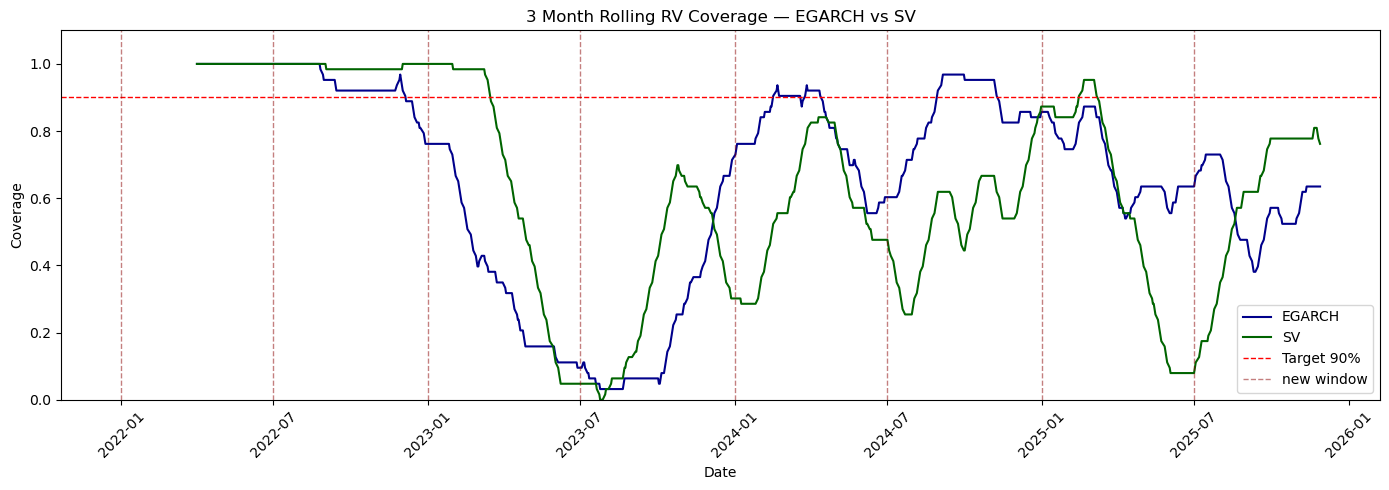

In [211]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_rv_egarch.index, rolling_rv_egarch,
        color='darkblue', lw=1.5, label='EGARCH')
ax.plot(rolling_rv_sv.index, rolling_rv_sv,
        color='darkgreen', lw=1.5, label='SV')
ax.axhline(0.90, color='red', linestyle='--', lw=1, label='Target 90%')

for date in window_start_dates:
    if date==window_start_dates[0]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.5, lw=1, label='new window')
    else:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.5, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Coverage")
ax.set_ylim(0, 1.1)
ax.set_title("3 Month Rolling RV Coverage — EGARCH vs SV")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sequential_rolling_rv_combined.pdf", bbox_inches='tight')
plt.show()

This graph basically shows the realized volatility coverage across the previous 3 months. 

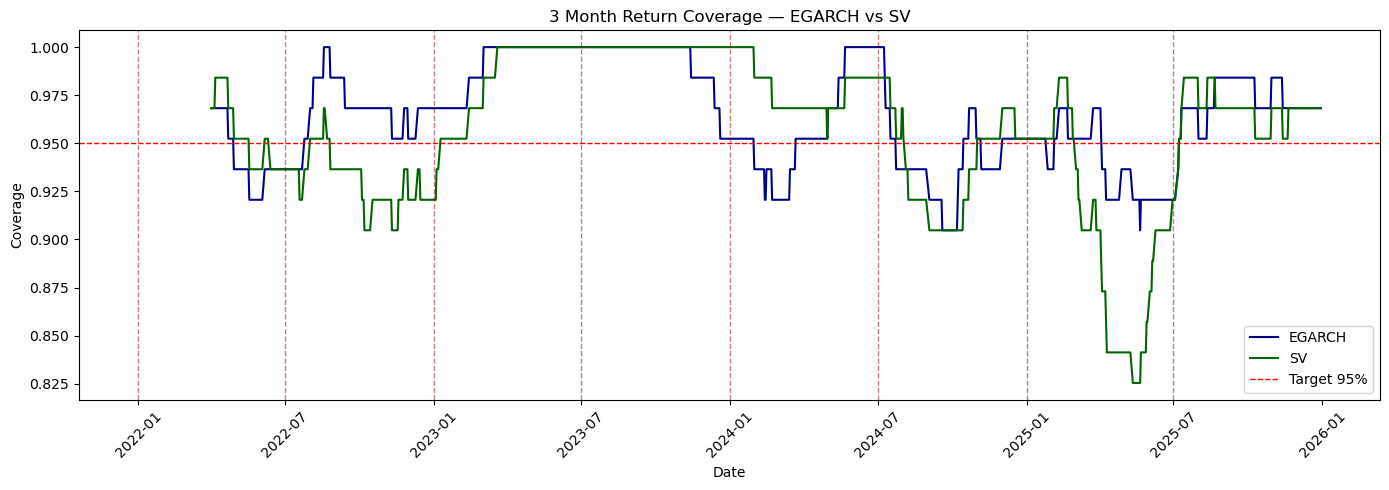

In [256]:
# ── Plot 3: Rolling 50-day PIT coverage combined ───────────────────────
rolling_pit_egarch = pd.Series(
    ((all_pit_egarch_arr >= 0.025) & 
     (all_pit_egarch_arr <= 0.975)).astype(float),
    index=sequential_returns.index[:len(all_pit_egarch_arr)]
).rolling(63).mean()

rolling_pit_sv = pd.Series(
    ((all_pit_sv_arr >= 0.025) & 
     (all_pit_sv_arr <= 0.975)).astype(float),
    index=sequential_returns.index[:len(all_pit_sv_arr)]
).rolling(63).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_pit_egarch.index, rolling_pit_egarch,
        color='darkblue', lw=1.5, label='EGARCH')
ax.plot(rolling_pit_sv.index, rolling_pit_sv,
        color='darkgreen', lw=1.5, label='SV')
ax.axhline(0.95, color='red', linestyle='--', lw=1, label='Target 95%')

for date in window_start_dates:
    if date < rolling_pit_egarch.index[-1]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.5, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Coverage")
ax.set_title("3 Month Return Coverage — EGARCH vs SV")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sequential_rolling_pit_combined.pdf", bbox_inches='tight')
plt.show()

### Sequential QLIKE

In [237]:
# ── Sequential QLIKE ───────────────────────────────────────────────────
rolling_vol_seq = full_rv.shift(21)["2022-01-01":"2025-12-31"].dropna().values.flatten()

# Sequential model vol — already in RV scale
sigma_mean_egarch_seq = seq_vol_rv_egarch
sigma_mean_sv_seq     = seq_vol_rv_sv_seq

# ── Align all lengths ──────────────────────────────────────────────────
n_dm_seq = min(len(rv_sequential_1d),
               len(rolling_vol_seq),
               len(sigma_mean_egarch_seq),
               len(sigma_mean_sv_seq))

rv_dm_seq = rv_sequential_1d[:n_dm_seq]

# ── QLIKE losses ───────────────────────────────────────────────────────
ql_rolling_seq = qlike(rolling_vol_seq[:n_dm_seq], rv_dm_seq)
ql_egarch_seq  = qlike(sigma_mean_egarch_seq[:n_dm_seq], rv_dm_seq)
ql_sv_seq      = qlike(sigma_mean_sv_seq[:n_dm_seq], rv_dm_seq)

# ── Results ────────────────────────────────────────────────────────────
print("Sequential Mean QLIKE (lower = better):")
print(f"Rolling: {ql_rolling_seq.mean():.6f}")
print(f"EGARCH:  {ql_egarch_seq.mean():.6f}")
print(f"SV:      {ql_sv_seq.mean():.6f}")



Sequential Mean QLIKE (lower = better):
Rolling: 0.395487
EGARCH:  0.101000
SV:      0.160691

DM test sequential (vs Rolling):
EGARCH vs Rolling: DM=10.0164, p=0.0000 → Model better, significant
SV vs Rolling: DM=9.2335, p=0.0000 → Model better, significant

DM test sequential (EGARCH vs SV):
EGARCH vs SV: DM=-6.7016, p=0.0000 → EGARCH better, significant


In [261]:
# ── Sequential QLIKE by window ─────────────────────────────────────────
print("Sequential Mean QLIKE by window (lower = better):")
print(f"{'':20} {'Rolling':>10} {'EGARCH':>10} {'SV':>10}")
print("-" * 55)

# Overall
print(f"{'Overall':20} {ql_rolling_seq.mean():>10.4f} "
      f"{ql_egarch_seq.mean():>10.4f} {ql_sv_seq.mean():>10.4f}")
print("-" * 55)

# Per window
cumulative = 0
for stat in all_window_stats_egarch:
    n_w      = stat['n_obs']
    end_idx  = min(cumulative + n_w, n_dm_seq)
    
    if cumulative >= n_dm_seq:
        break
    
    n_valid  = end_idx - cumulative
    
    ql_roll_w   = ql_rolling_seq[cumulative:end_idx]
    ql_egarch_w = ql_egarch_seq[cumulative:end_idx]
    ql_sv_w     = ql_sv_seq[cumulative:end_idx]
    
    print(f"W{stat['window']} {stat['start']}-{stat['end'][:7]} "
          f"{ql_roll_w.mean():>10.4f} "
          f"{ql_egarch_w.mean():>10.4f} "
          f"{ql_sv_w.mean():>10.4f}")
    
    cumulative += n_w

Sequential Mean QLIKE by window (lower = better):
                        Rolling     EGARCH         SV
-------------------------------------------------------
Overall                  0.3955     0.1010     0.1607
-------------------------------------------------------
W1 2022-01-01-2022-06     0.2578     0.0155     0.0170
W2 2022-07-01-2022-12     0.1093     0.0487     0.0429
W3 2023-01-01-2023-06     0.0842     0.1597     0.2396
W4 2023-07-01-2023-12     0.1296     0.1715     0.1690
W5 2024-01-01-2024-06     0.1702     0.0995     0.1231
W6 2024-07-01-2024-12     0.9491     0.0461     0.1334
W7 2025-01-01-2025-06     1.0283     0.1379     0.4826
W8 2025-07-01-2025-12     0.4464     0.1368     0.0741
